# ARoF MP-DPD

In [153]:
import sys

project_path = r"C:\Users\PC\Documents\Mestrado"
file_path    = project_path + r"\DPD"
sys.path.append(project_path)

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal           import welch, firwin, hilbert
from scipy.constants        import pi
from tqdm.notebook          import tqdm
from tabulate               import tabulate

from optic.comm.ofdm        import modulateOFDM, demodulateOFDM
from optic.comm.modulation  import modulateGray
from optic.models.channels  import linearFiberChannel
from optic.models.devices   import mzm, photodiode
from optic.comm.metrics     import fastBERcalc, theoryBER, calcEVM
from optic.dsp.core         import pnorm, signal_power, upsample, pulseShape, decimate, finddelay
from optic.dsp.coreGPU      import firFilter
from optic.utils            import parameters, dBm2W
from optic_private.dsp.core import calcACLR

from DPD_utils.MP_tools     import powerAmplifier, MP_filter, LS_solver, MP_training, calcSNR_per_carrier
from DPD_utils.plots        import calc_per_carrier

In [43]:
font = {'size':16}
plt.rc('font', **font)
plt.rcParams["font.family"] = "serif"

### 1 - Geração do Sinal OFDM

In [4]:
# Parâmetros de modulação
modOrder = 64                          # Ordem da modulação
modType  = 'qam'                       # Tipo de modulação
Rb = 5e9                               # Taxa de transmissão de bits
SpS = 32                               # Amostras por símbolo

# Parâmetros OFDM
paramOFDM = parameters()
paramOFDM.Nfft = 1024                  # Tam. da FFT
paramOFDM.G    = 32                    # Tam. do prefixo cíclico
paramOFDM.hermitSymmetry = False
paramOFDM.SpS = SpS
paramOFDM.returnChannel = False

if paramOFDM.hermitSymmetry:
    Ns = paramOFDM.Nfft//2 - 1
    paramOFDM.pilotCarriers = np.linspace(0, Ns - 1, 8, dtype = np.int64)
    paramOFDM.nullCarriers  = np.array([], dtype = np.int64)
else:
    Ns = paramOFDM.Nfft
    paramOFDM.pilotCarriers = np.linspace(0, Ns - 1, 8, dtype = np.int64)
    paramOFDM.nullCarriers  = np.array([paramOFDM.Nfft//2], dtype = np.int64)

# Núm. de subportadoras de informação
Np = paramOFDM.pilotCarriers.size
Nz = paramOFDM.nullCarriers.size
Ni = Ns - Np - Nz

Rs = Rb / ( Ni/(paramOFDM.Nfft + paramOFDM.G) * np.log2(modOrder) )    # Taxa de transmissão de símbolos
Fs = Rs * SpS                                                          # Taxa de amostragem

# Geração dos bits e dos símbolos QAM
numOFDMframes = 500
np.random.seed(2)
bits = np.random.randint(2, size = (numOFDMframes*Ni, int(np.log2(modOrder))))

symbTx = modulateGray(bits, modOrder, modType)
symbTx = pnorm(symbTx)

pilotSymb = 0.25*(max(symbTx.real) + 1j*max(symbTx.imag))
paramOFDM.pilot = pilotSymb

In [5]:
sigTx = modulateOFDM(symbTx, paramOFDM)
sigTx = pnorm(sigTx)

t = np.arange(0, sigTx.size)*1/Fs
t_CP   = SpS * paramOFDM.G * (1/Fs)
t_symb = SpS * (paramOFDM.Nfft + paramOFDM.G) * (1/Fs)

In [6]:
table = [['Grandeza', 'Parâmetro', 'Valor'],
         ['Taxa de amostragem', 'Fs', f'{Fs*1e-9:.2f} Gsamples/s'],
         ['Taxa de símbolos', 'Rs', f'{Rs*1e-9:.2f} Gsymb/s'],
         ['Taxa de transmissão', 'Rb', f'{Rb*1e-9:.2f} Gb/s'],
         ['Ordem da constelação', 'M', f'{modOrder}'],
         ['Tamanho da FFT', 'Nfft', f'{paramOFDM.Nfft}'],
         ['Tamanho do prefixo cíclico', 'G', f'{paramOFDM.G}'],
         ['Num. port. de informação', 'Ns', f'{Ni}'],
         ['Num. port. piloto', 'Np', f'{Np}'],
         ['Num. port. nulas', 'Nz', f'{Nz}'],
         ['Espaçamento entre subportadoras', 'Delta_f', f'{(Rs/paramOFDM.Nfft)*1e-6:.2f} MHz'],
         ['Duração do símbolo OFDM', 'T_symb', f'{1e9*t_symb:.2f} ns'],
         ['Duração do prefixo cíclico', 'T_CP', f'{1e9*t_CP:.2f} ns'] ]

print(tabulate(table, headers = 'firstrow', tablefmt = 'fancy_grid'))

╒═════════════════════════════════╤═════════════╤══════════════════╕
│ Grandeza                        │ Parâmetro   │ Valor            │
╞═════════════════════════════════╪═════════════╪══════════════════╡
│ Taxa de amostragem              │ Fs          │ 27.74 Gsamples/s │
├─────────────────────────────────┼─────────────┼──────────────────┤
│ Taxa de símbolos                │ Rs          │ 0.87 Gsymb/s     │
├─────────────────────────────────┼─────────────┼──────────────────┤
│ Taxa de transmissão             │ Rb          │ 5.00 Gb/s        │
├─────────────────────────────────┼─────────────┼──────────────────┤
│ Ordem da constelação            │ M           │ 64               │
├─────────────────────────────────┼─────────────┼──────────────────┤
│ Tamanho da FFT                  │ Nfft        │ 1024             │
├─────────────────────────────────┼─────────────┼──────────────────┤
│ Tamanho do prefixo cíclico      │ G           │ 32               │
├─────────────────────────────────

In [7]:
## Parametrização dos dispositivos

# Parâmetros do MZM
paramMZM = parameters()
paramMZM.Vpi = 3
paramMZM.Vb = -paramMZM.Vpi*0.5
paramMZM.Pin_OF = 10

# Parâmetros do canal óptico
paramChannel = parameters()
paramChannel.L = 25
paramChannel.alpha = 0.2
paramChannel.D = 16
paramChannel.Fc = 193.1e12
paramChannel.Fs = Fs

#
paramRF = parameters()
paramRF.fc_e = 7.5e9
paramRF.Pin_RF = 17
paramRF.Pin_PA = 5

# Parâmetros do fotodiodo
paramPD = parameters()
paramPD.ideal = False
paramPD.B = paramRF.fc_e + 2*Rs
paramPD.Ipd_sat = 50e-3
paramPD.Fs = Fs

### 2 Canal RoF

#### 2.1 Sinal RF

In [8]:
sigTx_RF = np.real( sigTx * np.exp(1j*2*pi*paramRF.fc_e*t) )
G_1 = 10**( np.log10(dBm2W(paramRF.Pin_RF)/signal_power(sigTx_RF))/2)
sigTx_RF *= G_1

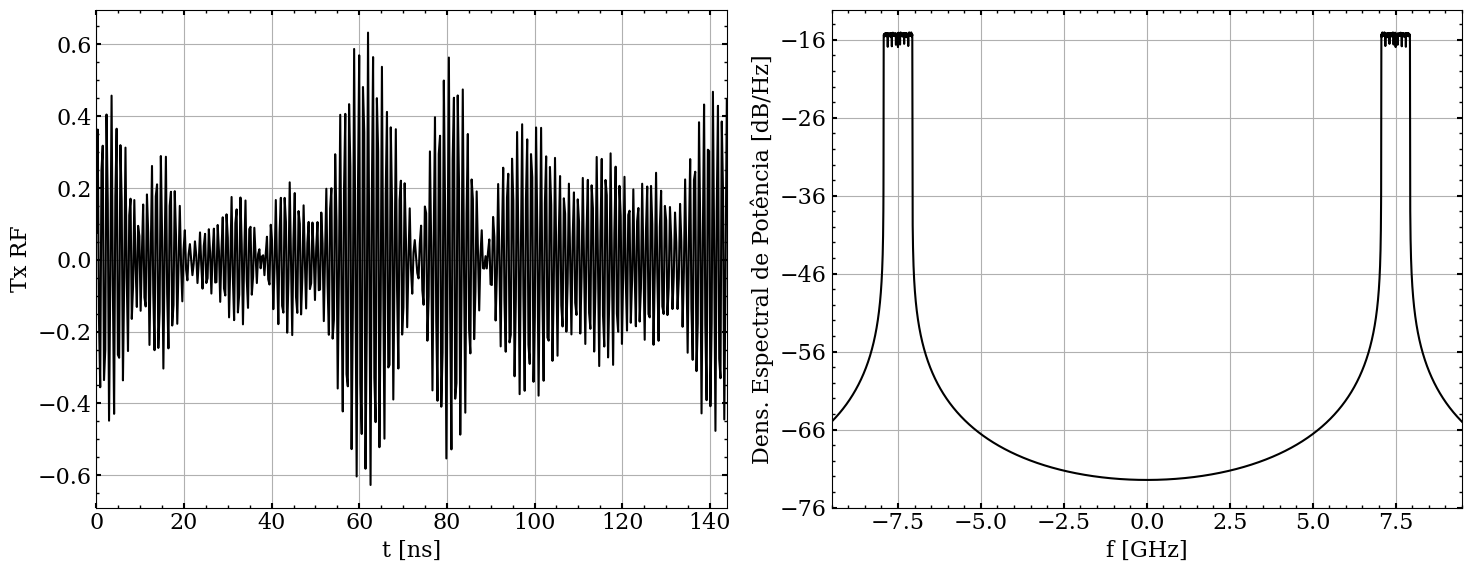

In [98]:

indx = np.arange(0, 500)

fig, axs = plt.subplots(1, 2, figsize = (15, 6))

axs[0].plot(t[indx]*1e9, sigTx_RF[indx], "k")
axs[1].psd(sigTx_RF, Fs = Fs/1e9, NFFT = 16*1024, sides = 'twosided', color = "k")

axs[0].set_xlim(0, t[indx][-1]*1e9)
axs[0].set_xlabel("t [ns]")
axs[0].set_ylabel("Tx RF")
axs[0].grid()
axs[0].minorticks_on()
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

axs[1].set_xlabel("f [GHz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(-paramRF.fc_e/1e9 - 2, paramRF.fc_e/1e9 + 2)
axs[1].grid(True)
axs[1].minorticks_on()
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

plt.tight_layout()
plt.show()

#### 2.2 Sinal óptico

In [10]:
Ai     = np.sqrt(dBm2W(paramMZM.Pin_OF))*np.ones(sigTx_RF.size)
sigTxo = mzm(Ai, sigTx_RF, paramMZM)

numtaps = 4096
hopt_tx = firwin(numtaps, paramRF.fc_e + 2*Rs, fs = Fs)
sigTxo = np.sqrt(signal_power(sigTxo))*pnorm(firFilter(hopt_tx, sigTxo))

sigRxo = linearFiberChannel(sigTxo, paramChannel)

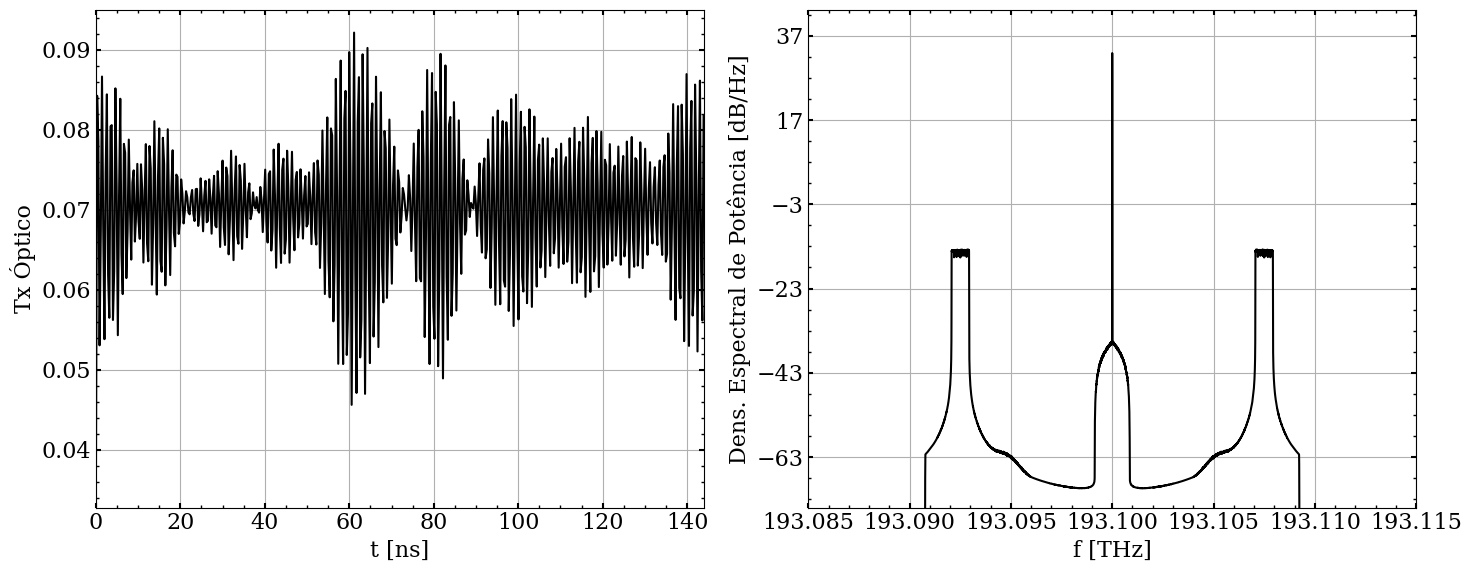

In [99]:
indx = np.arange(0, 500)
fig, axs = plt.subplots(1, 2, figsize = (15, 6))

axs[0].plot(t[indx]*1e9, sigTxo[indx], "k")
axs[1].psd(np.abs(sigTxo), Fs = Fs/1e12, Fc = paramChannel.Fc/1e12, NFFT = 16*1024, sides = 'twosided', color = "k")

axs[0].set_xlim(0, t[indx][-1]*1e9)
axs[0].set_xlabel("t [ns]")
axs[0].set_ylabel("Tx Óptico")
axs[0].grid()
axs[0].minorticks_on()
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

axs[1].set_xlabel("f [THz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(-0.015 + paramChannel.Fc/1e12, 0.015 + paramChannel.Fc/1e12)
axs[1].set_ylim(-75)
axs[1].grid(True)
axs[1].minorticks_on()
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

plt.tight_layout()
plt.show()

#### 2.3 Sinal elétrico (fotocorrente)

In [62]:
I_Rx = photodiode(sigRxo, paramPD)
I_Rx -= I_Rx.mean()

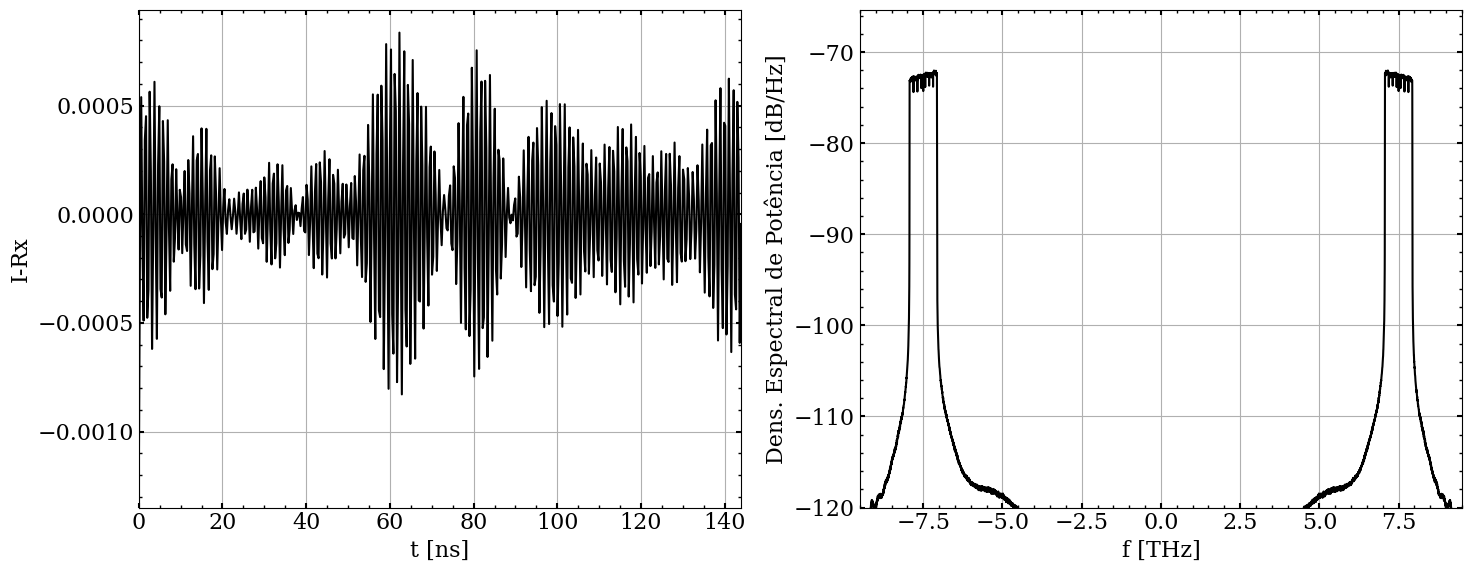

In [100]:

indx = np.arange(0, 500)
fig, axs = plt.subplots(1, 2, figsize = (15, 6))

axs[0].plot(t[indx]*1e9, I_Rx[indx], "k")
axs[1].psd(I_Rx, Fs = Fs/1e9, NFFT = 16*1024, sides = 'twosided', color = "k")

axs[0].set_xlim(0, t[indx][-1]*1e9)
axs[0].set_xlabel("t [ns]")
axs[0].set_ylabel("I-Rx")
axs[0].grid()
axs[0].minorticks_on()
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

axs[1].set_xlabel("f [THz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(- paramRF.fc_e/1e9 - 2,  paramRF.fc_e/1e9 + 2)
axs[1].set_ylim(-120)
axs[1].grid(True)
axs[1].set_yticks(np.arange(-120, -60, 10))
axs[1].minorticks_on()
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

plt.tight_layout()
plt.show()

#### 2.4 Sinal elétrico pós-FPF

In [64]:
# Filtro passa-faixas
numtaps = 4096
f1 = paramRF.fc_e - 2*Rs
f2 = paramRF.fc_e + 2*Rs
hbp_RF = firwin(numtaps, (f1, f2), pass_zero = 'bandpass', fs = Fs)

I_RF = firFilter(hbp_RF, I_Rx)

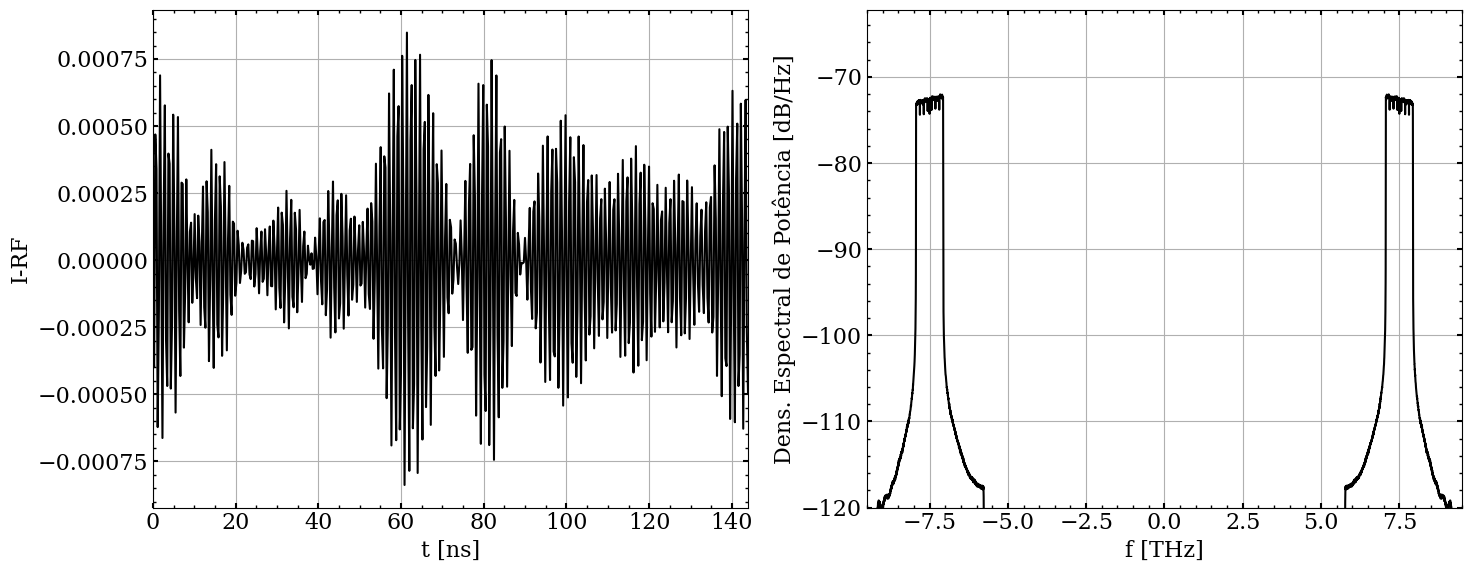

In [101]:

indx = np.arange(0, 500)
fig, axs = plt.subplots(1, 2, figsize = (15, 6))

axs[0].plot(t[indx]*1e9, I_RF[indx], "k")
axs[1].psd(I_RF, Fs = Fs/1e9, NFFT = 16*1024, sides = 'twosided', color = "k")

axs[0].set_xlim(0, t[indx][-1]*1e9)
axs[0].set_xlabel("t [ns]")
axs[0].set_ylabel("I-RF")
axs[0].grid()
axs[0].minorticks_on()
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

axs[1].set_xlabel("f [THz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(- paramRF.fc_e/1e9 - 2,  paramRF.fc_e/1e9 + 2)
axs[1].set_ylim(-120)
axs[1].grid(True)
axs[1].set_yticks(np.arange(-120, -60, 10))
axs[1].minorticks_on()
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

plt.tight_layout()
plt.show()

#### 2.5 Sinal elétrico pós-PA

In [16]:
sigRx = hilbert(I_RF)*np.exp(-1j*2*pi*paramRF.fc_e*t)
G_2 = 10**( np.log10(dBm2W(paramRF.Pin_PA)/signal_power(sigRx))/2)
sigRx *= G_2

sigRx = powerAmplifier(sigRx)

sigRx_PA = sigRx.copy()
G_3 = 10**( np.log10(signal_power(sigTx)/signal_power(sigRx_PA))/2)
sigRx_PA *= G_3

numtaps = 4096
hlp = firwin(numtaps, Rs/1.5, fs = Fs)
#sigRx = firFilter(hlp, sigRx)

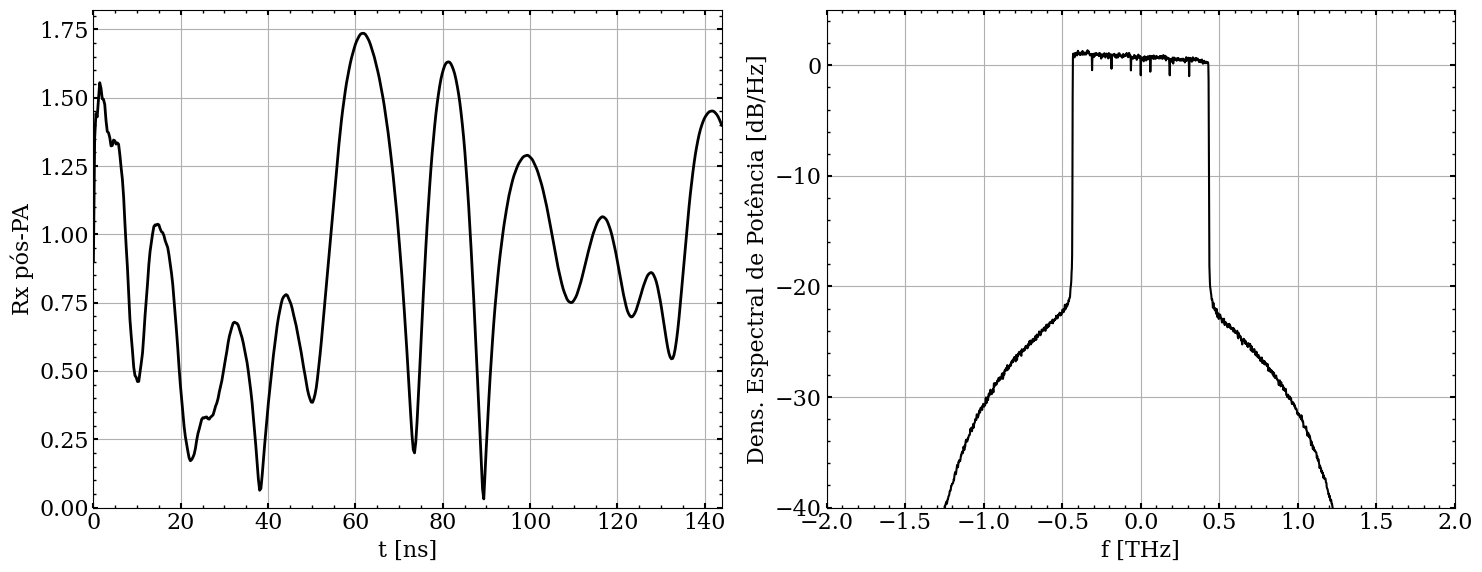

In [102]:

indx = np.arange(0, 500)
fig, axs = plt.subplots(1, 2, figsize = (15, 6))

axs[0].plot(t[indx]*1e9, np.abs(sigRx_PA[indx]), "k", lw = 2)
axs[1].psd(sigRx_PA, Fs = Fs/1e9, NFFT = 16*1024, sides = 'twosided', color = "k")

axs[0].set_xlim(0, t[indx][-1]*1e9)
axs[0].set_xlabel("t [ns]")
axs[0].set_ylabel("Rx pós-PA")
axs[0].set_ylim(0)
axs[0].grid()
axs[0].minorticks_on()
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

axs[1].set_xlabel("f [THz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(-2, 2)
axs[1].set_ylim(-40, 5)
axs[1].grid(True)
axs[1].set_yticks(np.arange(-40, 5, 10))
axs[1].minorticks_on()
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

plt.tight_layout()
plt.show()

In [67]:
delay = finddelay(sigRx, sigTx)
sigRx = np.roll(sigRx, -delay)

rot = np.mean(sigTx/sigRx)
sigRx = rot/np.abs(rot)*sigRx

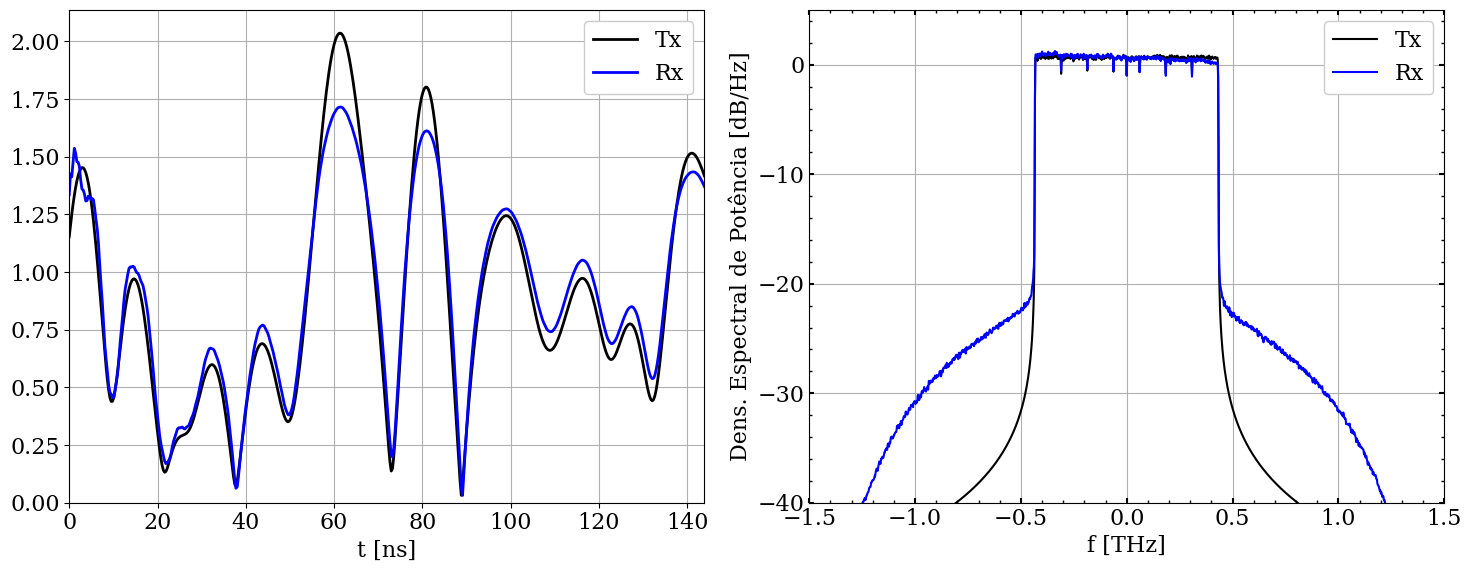

In [95]:

indx = np.arange(0, 500)
fig, axs = plt.subplots(1, 2, figsize = (15, 6))

axs[0].plot(t[indx]*1e9, np.abs(pnorm(sigTx))[indx], label = "Tx", lw = 2, color = "k")
axs[0].plot(t[indx]*1e9, np.abs(pnorm(sigRx))[indx], label = "Rx", lw = 2, color = "b")

axs[1].psd(pnorm(sigTx), Fs = Fs/1e9, NFFT = 16*1024, sides = 'twosided', label = "Tx", color = "k")
axs[1].psd(pnorm(sigRx), Fs = Fs/1e9, NFFT = 16*1024, sides = 'twosided', label = "Rx", color = "b")

axs[0].set_xlim(0, t[indx][-1]*1e9)
axs[0].set_xlabel("t [ns]")
axs[0].set_ylim(0)
axs[0].grid()
axs[0].legend(framealpha = 1)

axs[1].set_xlabel("f [THz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(-1.5, 1.5)
axs[1].set_ylim(-40, 5)
axs[1].grid(True)
axs[1].set_yticks(np.arange(-40, 5, 10))
axs[1].minorticks_on()
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs[1].legend(framealpha = 1)

plt.tight_layout()
plt.show()

#### 2.6 Performance

In [22]:
# Parâmetros da decimação
paramDec = parameters()
paramDec.SpS_in  = SpS
paramDec.SpS_out = 1

symbRx_OFDM = decimate(sigRx, paramDec).ravel()
symbRx = demodulateOFDM(symbRx_OFDM, paramOFDM)

BER = 0.00858 
SNR = 20.014 dB


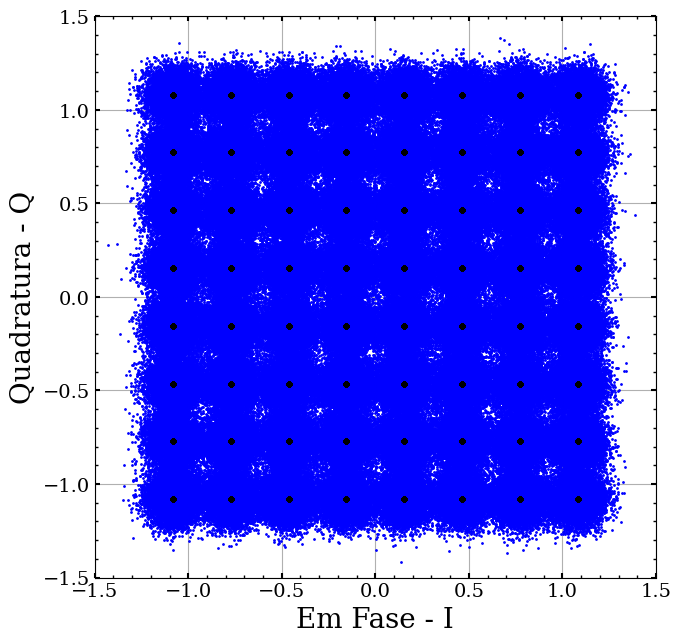

In [23]:
discard = Ni
index = np.arange(discard, symbTx.size - discard)
BER, SER, SNR = fastBERcalc(symbRx[index], symbTx[index], modOrder, modType)

EVM = 10*np.log10(calcEVM(symbRx, modOrder, modType))

print(f"BER = {BER[0]:.5f} \nSNR = {SNR[0]:.3f} dB")

# Normalização para o plot
symbTx = pnorm(symbTx)
symbRx = pnorm(symbRx)

fig, axs = plt.subplots(figsize = (7, 7))
axs.plot(symbRx.real, symbRx.imag, "o", color = "b", ms = 1, label = "SymbRx")
axs.plot(symbTx.real, symbTx.imag, "o", color = "k", ms = 3, label = "SymbTx")
axs.set_ylabel("Quadratura - Q", fontsize = 20)
axs.set_xlabel("Em Fase - I", fontsize = 20)
plt.axis("square")

axs.set_xlim(-1.5, 1.5)
axs.set_ylim(-1.5, 1.5)
axs.minorticks_on()
axs.tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs.tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
plt.grid()

plt.tight_layout()
plt.savefig("constelacao_noDPD.png")

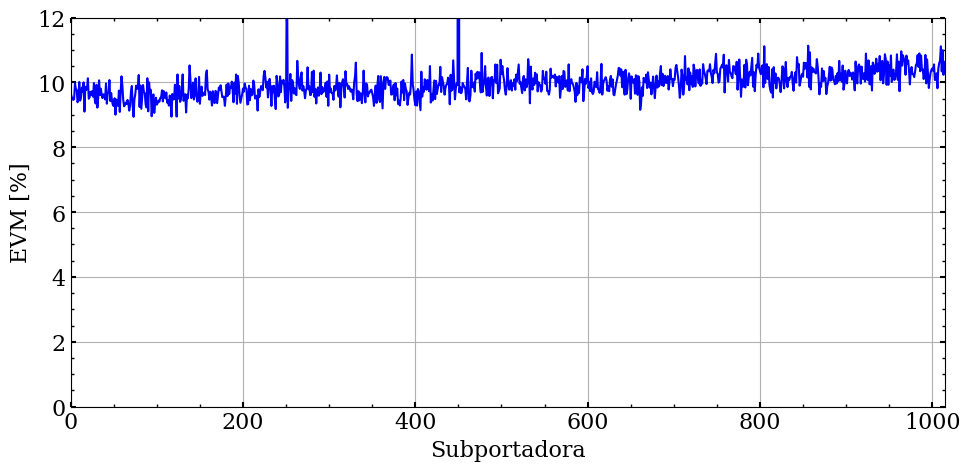

In [103]:
_, SNR_per_carrier, EVM_per_carrier = calc_per_carrier(symbTx, symbRx, Ni, numOFDMframes)

fig, axs = plt.subplots(figsize = (10, 5))
axs.plot(EVM_per_carrier, color = "b")
axs.set_xlim(0, Ni)
axs.set_ylim(0, 12)
axs.set_ylabel("EVM [%]")
axs.set_xlabel("Subportadora")
axs.grid()
axs.minorticks_on()
axs.tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs.tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
plt.tight_layout()

### 3 Identificação do canal

In [25]:
SpS_mp = 4

paramDec = parameters()
paramDec.SpS_in = SpS
paramDec.SpS_out = SpS_mp

hlp = firwin(numtaps, SpS_mp*Rs/2, fs = Fs)

sigRef = decimate(pnorm(firFilter(hlp, sigTx)), paramDec).ravel()
sigIn  = decimate(pnorm(firFilter(hlp, sigRx_PA)), paramDec).ravel()

In [26]:
delay = finddelay(sigIn, sigRef)
sigIn = np.roll(sigIn, -delay)

rot = np.mean(sigRef/sigIn)
sigIn = rot/np.abs(rot)*sigIn

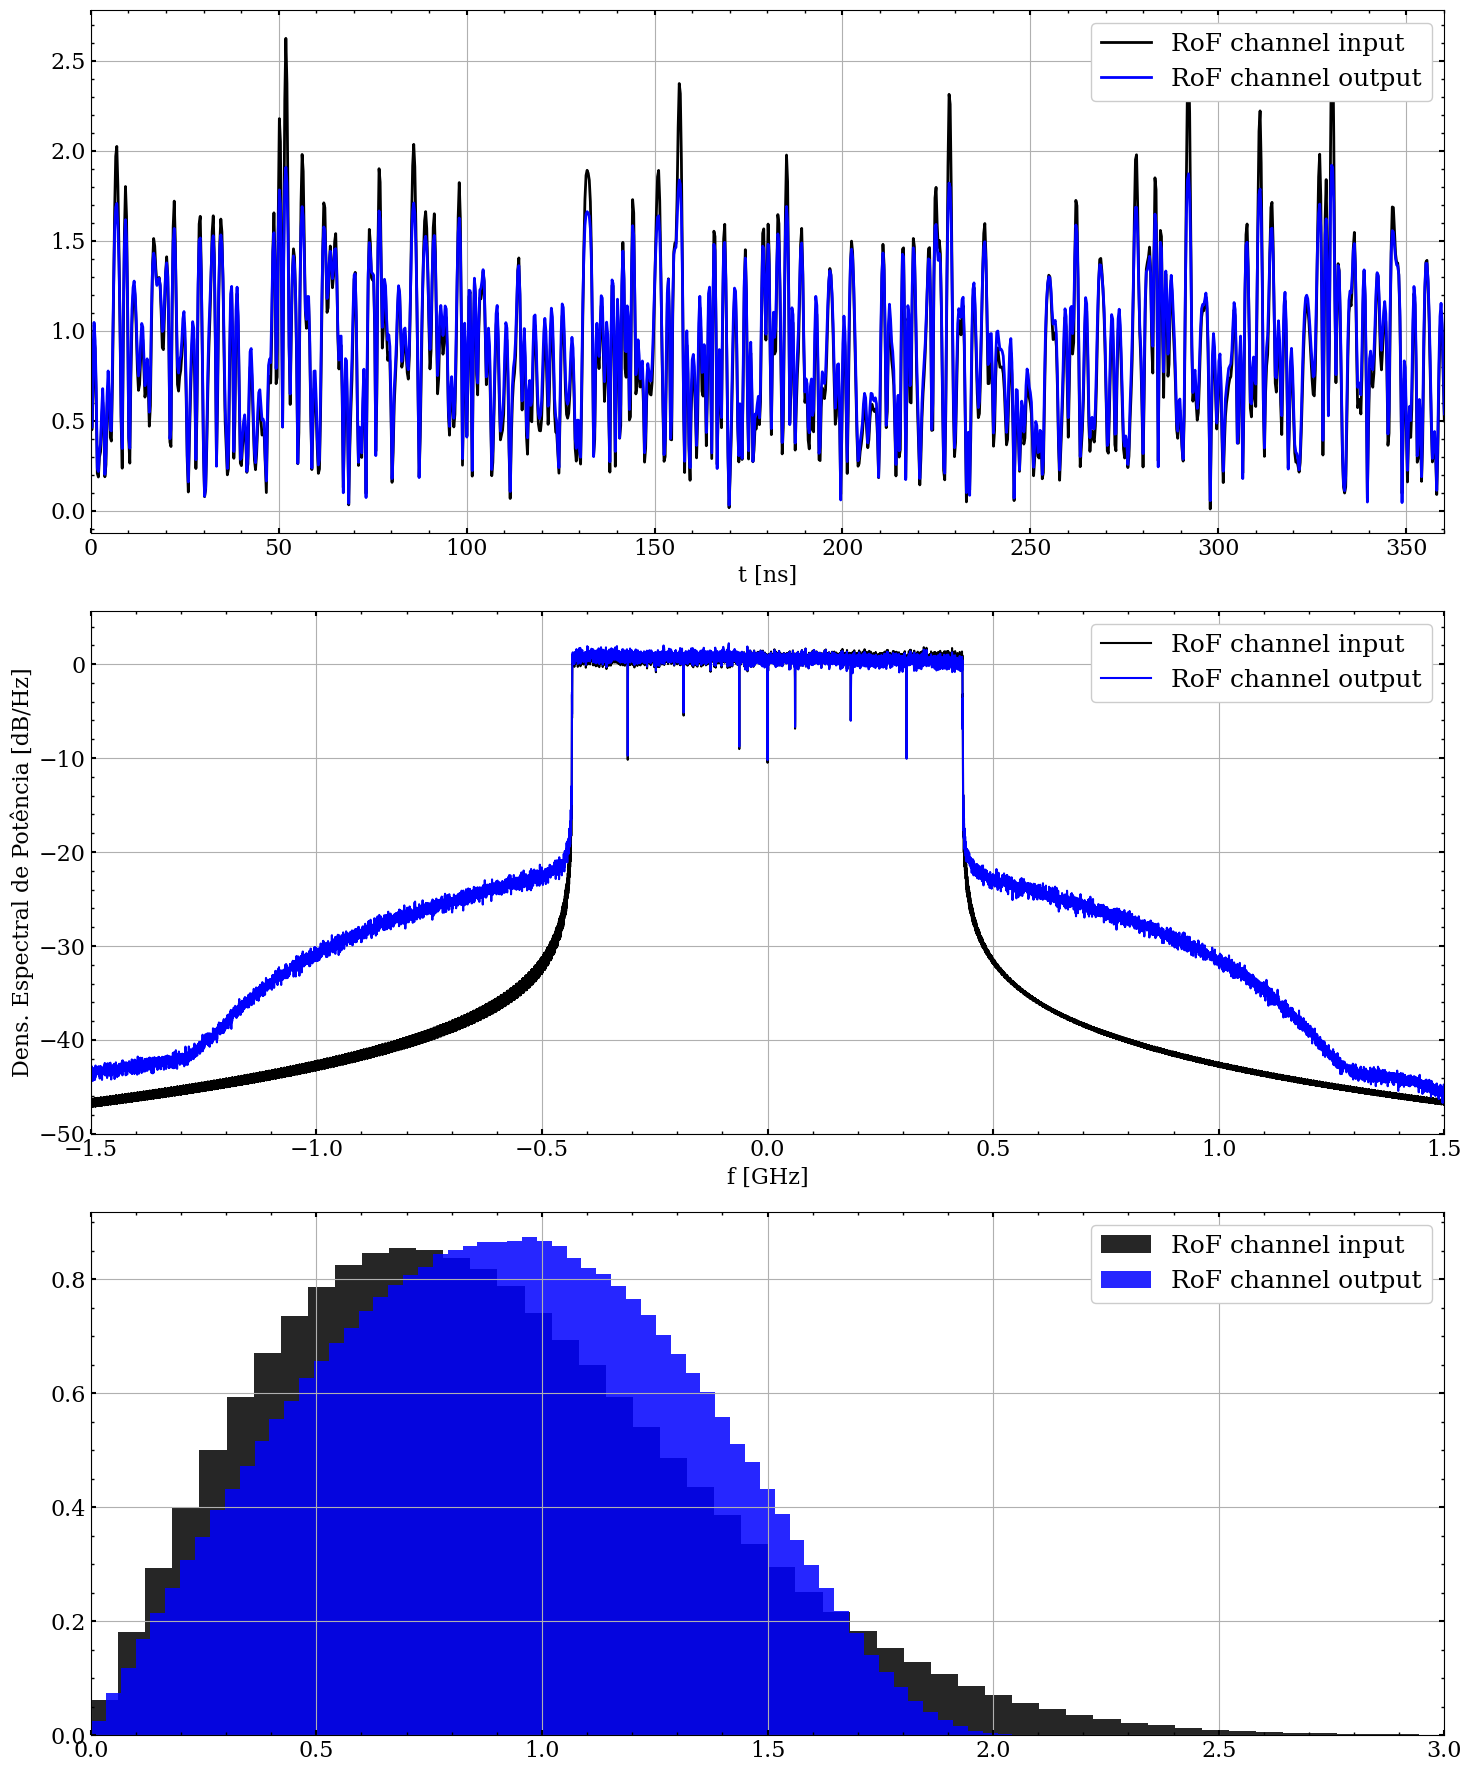

In [97]:
indx = np.arange(0, int(10000*SpS_mp/SpS))
fig, axs = plt.subplots(3, 1, figsize = (15, 18))
t = np.arange(0, sigRef.size)*(1/Fs)*(SpS/SpS_mp)

axs[0].plot(t[indx]*1e9, np.abs(sigRef[indx]), "k", lw = 2, label = "RoF channel input")
axs[0].plot(t[indx]*1e9, np.abs(sigIn[indx]), "b", lw = 2, label = "RoF channel output")

axs[1].psd(sigRef, Fs = (SpS_mp/SpS)*Fs/1e9, NFFT = 16*1024, sides = 'twosided', color = "k", label = "RoF channel input")
axs[1].psd(sigIn, Fs = (SpS_mp/SpS)*Fs/1e9, NFFT = 16*1024, sides = 'twosided', color = "b", label = "RoF channel output")

axs[0].set_xlim(0, np.max(t[indx]*1e9))
axs[0].set_xlabel("t [ns]")
axs[0].grid()
axs[0].minorticks_on()
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs[0].legend(framealpha = 1, fontsize = 18, loc = "upper right")

axs[1].set_xlabel("f [GHz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(-1.5, 1.5)
axs[1].set_ylim(-50)
axs[1].grid(True)
axs[1].minorticks_on()
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs[1].legend(framealpha = 1, fontsize = 18, loc = "upper right")

axs[2].hist(np.abs(sigRef), color = "k", density = True, bins = 64, label = 'RoF channel input', alpha = 0.85)
axs[2].hist(np.abs(sigIn), color = "b", density = True, bins = 64, label = 'RoF channel output', alpha = 0.85)
axs[2].set_xlim(0, 3)
axs[2].grid()
axs[2].minorticks_on()
axs[2].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[2].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs[2].legend(framealpha = 1, fontsize = 18, loc = "upper right")

plt.tight_layout()
plt.show()

In [ ]:
K_sweep = np.arange(1, 8)
L_sweep = np.arange(1, 8)

MSE_matrix = np.zeros((K_sweep.size, L_sweep.size))
N = 10000

for i, kk in tqdm(enumerate(K_sweep)):
    for j, ll in enumerate(L_sweep):
        a_kl = LS_solver(sigRef[0:N], sigIn[0:N], kk, ll)
        sig_mp = MP_filter(sigRef, a_kl)
        MSE_matrix[i,j] = 10*np.log10(np.mean(np.abs(sig_mp - sigIn)**2))

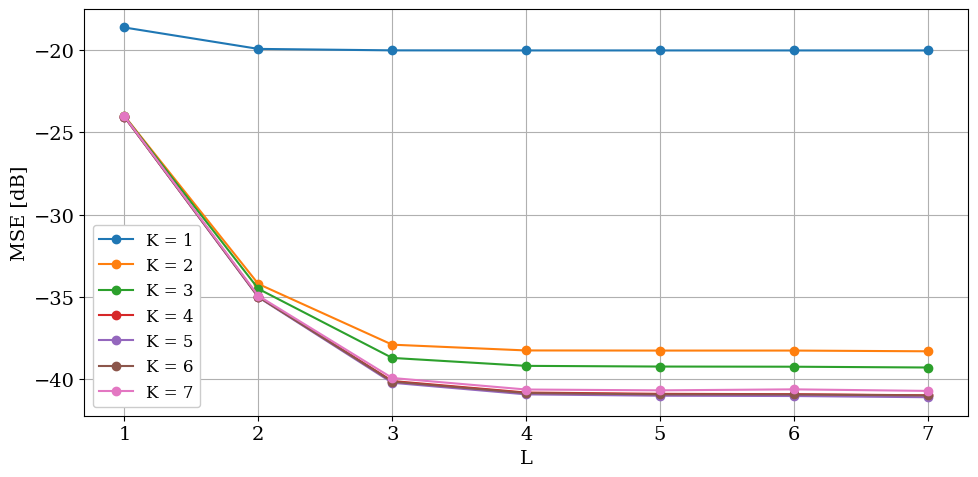

In [961]:

plt.figure(figsize = (10, 5))

for i, kk in enumerate(K_sweep):
    plt.plot(L_sweep, MSE_matrix[i,:], "-o", label = f"K = {kk}")

plt.xticks(L_sweep)
plt.legend(fontsize = 12, framealpha = 1)
plt.ylabel("MSE [dB]")
plt.xlabel("L")
plt.grid()
plt.tight_layout()

In [104]:
P = 3
M = 2

K = 3
L = 2

N = 50_000

a_kl   = LS_solver(sigRef[0:N], sigIn[0:N], K, L)
sig_mp = MP_filter(sigRef, a_kl)
sig_mp = pnorm(sig_mp)

In [105]:
sig_mp = MP_filter(sigRef, a_kl)
sig_mp = pnorm(sig_mp)

MSE = -36.850 dB


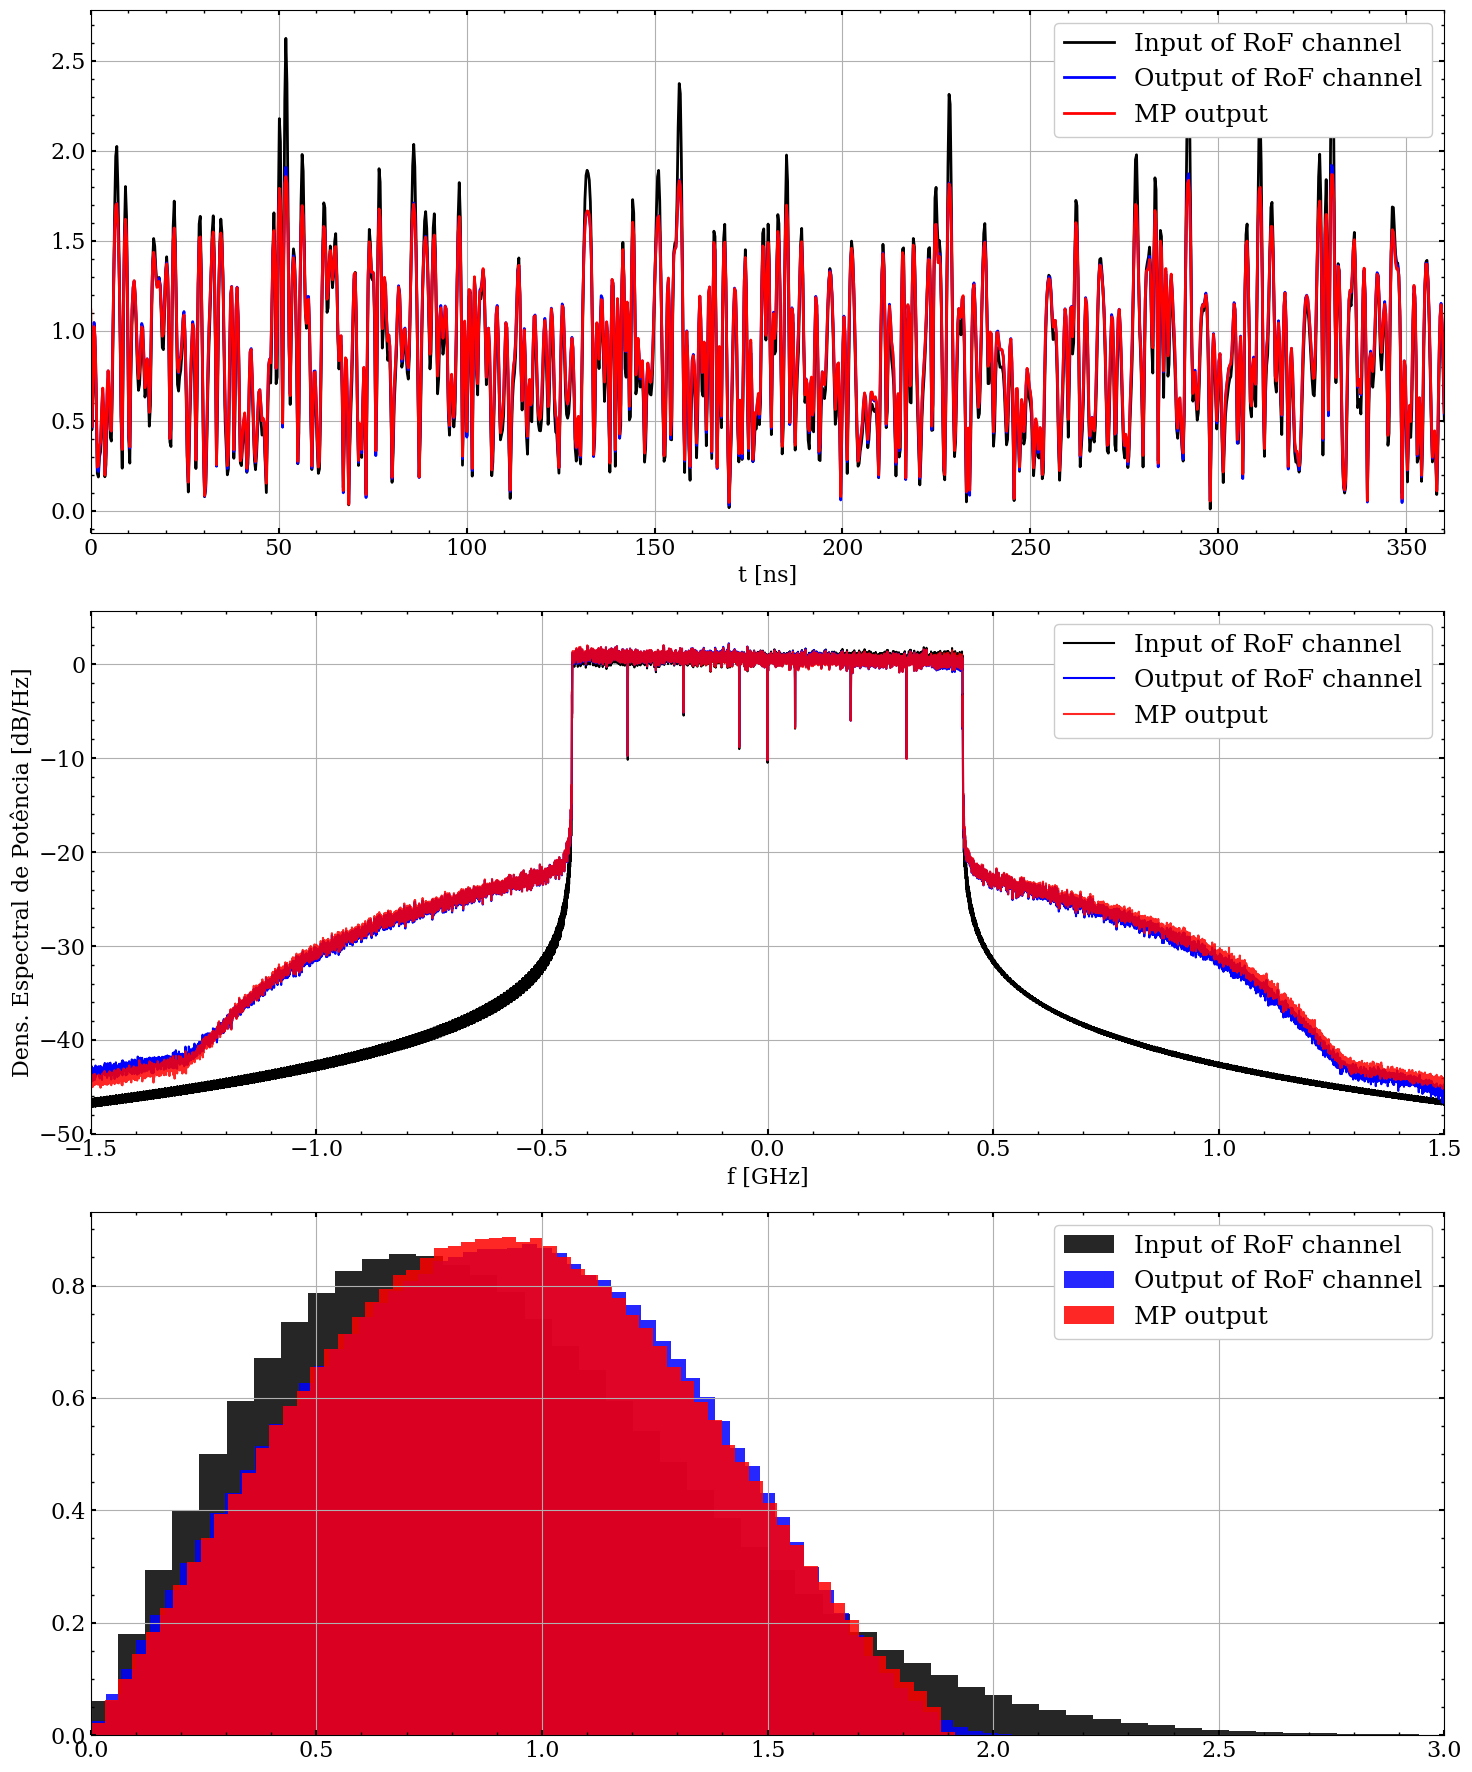

In [110]:
indx = np.arange(0, int(10000*SpS_mp/SpS))
fig, axs = plt.subplots(3, 1, figsize = (15, 18))
t = np.arange(0, sigRef.size)*(1/Fs)*(SpS/SpS_mp)

print(f"MSE = {10*np.log10(np.mean(np.abs(sig_mp - sigIn)**2)):.3f} dB")

axs[0].plot(t[indx]*1e9, np.abs(sigRef[indx]), "k", lw = 2, label = "Input of RoF channel")
axs[0].plot(t[indx]*1e9, np.abs(sigIn[indx]),  "b", lw = 2, label = "Output of RoF channel")
axs[0].plot(t[indx]*1e9, np.abs(sig_mp[indx]), "r", lw = 2, label = "MP output")

axs[0].set_xlim(0, np.max(t[indx])*1e9)
axs[0].legend(framealpha = 1, fontsize = 18, loc = "upper right")
axs[0].set_xlabel("t [ns]")
axs[0].grid()
axs[0].minorticks_on()
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

axs[1].psd(sigRef, Fs = (SpS_mp/SpS)*Fs/1e9, NFFT = 16*1024, sides = 'twosided', color = "k", label = "Input of RoF channel")
axs[1].psd(sigIn, Fs = (SpS_mp/SpS)*Fs/1e9, NFFT = 16*1024, sides = 'twosided', color = "b", label = "Output of RoF channel")
axs[1].psd(sig_mp, Fs = (SpS_mp/SpS)*Fs/1e9, NFFT = 16*1024, sides = 'twosided', color = "r", label = "MP output", alpha = 0.85)
axs[1].set_xlabel("f [GHz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(-1.5, 1.5)
axs[1].set_ylim(-50)
axs[1].grid(True)
axs[1].minorticks_on()
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs[1].legend(framealpha = 1, fontsize = 18, loc = "upper right")

axs[2].hist(np.abs(sigRef), density = True, bins = 64, color = "k", label = 'Input of RoF channel', alpha = 0.85)
axs[2].hist(np.abs(sigIn), density = True, bins = 64, color = "b", label = 'Output of RoF channel', alpha = 0.85)
axs[2].hist(np.abs(sig_mp), density = True, bins = 64, color = "r", label = 'MP output', alpha = 0.85)
axs[2].set_xlim(0, 3)
axs[2].grid()
axs[2].minorticks_on()
axs[2].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[2].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs[2].legend(framealpha = 1, fontsize = 18, loc = "upper right")

plt.tight_layout()
plt.show()

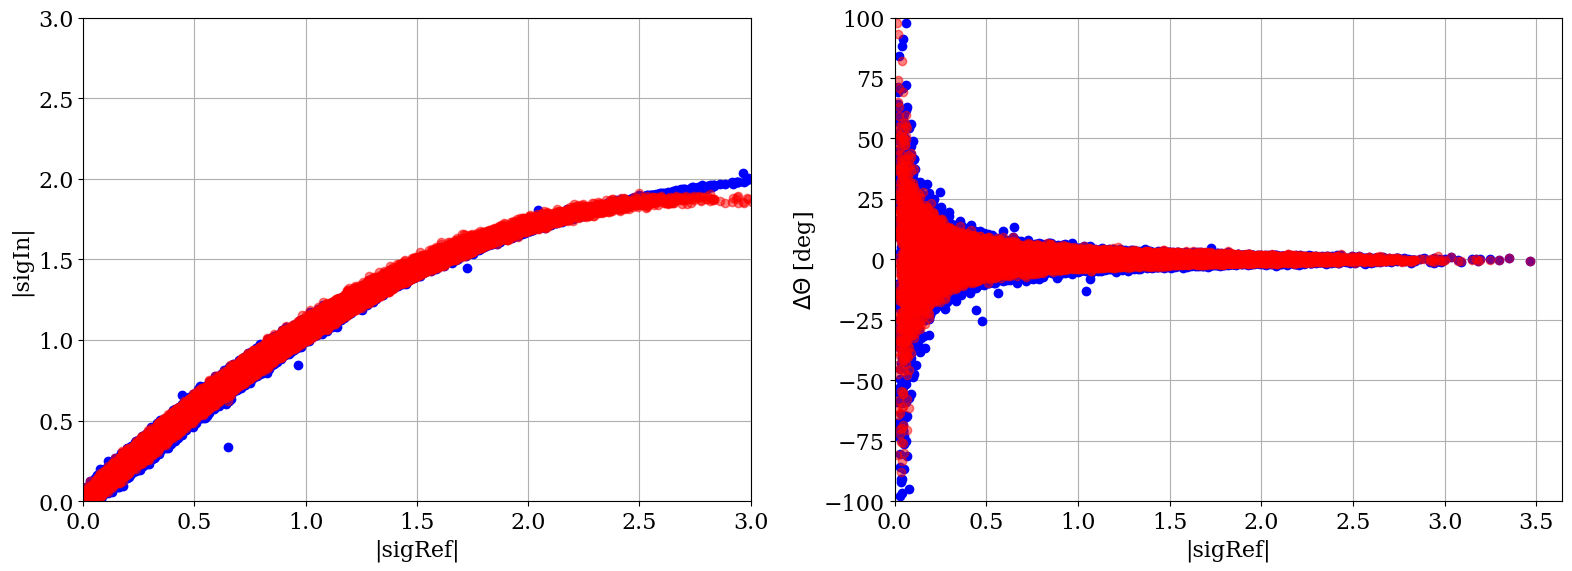

In [108]:
fig, axs = plt.subplots(1, 2, figsize = (16, 6))

n_pts = 100_000

axs[0].plot(np.abs(sigRef[0:n_pts]), np.abs(sigIn[0:n_pts]), "o", color = "b")
axs[0].plot(np.abs(sigRef[0:n_pts]), np.abs(sig_mp[0:n_pts]), "o", color = "r", alpha = 0.5)
axs[0].set_xlim(0,3)
axs[0].set_ylim(0,3)
axs[0].set_xlabel("|sigRef|")
axs[0].set_ylabel("|sigIn|")
axs[0].grid()

axs[1].plot(np.abs(sigRef[0:n_pts]), (np.angle(sigIn) - np.angle(sigRef))[0:n_pts]*180/pi, "o", color = "b")
axs[1].plot(np.abs(sigRef[0:n_pts]), (np.angle(sig_mp) - np.angle(sigRef))[0:n_pts]*180/pi, "o", color = "r", alpha = 0.5)
axs[1].set_xlim(0)
axs[1].set_ylim(-100, 100)
axs[1].set_xlabel("|sigRef|")
axs[1].set_ylabel("$\Delta \Theta$ [deg]")
axs[1].grid()

plt.tight_layout()

### 4 - Arquitetura de Aprendizado Indireto (ILA)

In [ ]:
paramTrain = parameters()
paramTrain.M = M
paramTrain.P = P

paramTrain.N = 20_000
paramTrain.numIter = 5

paramTrain.mu  = 1e-3
paramTrain.lbd = 0.9999
paramTrain.S   = np.eye(paramTrain.P*paramTrain.M, dtype = complex)*5e-2

paramTrain.alg = "RLS"
paramTrain.a_kl = a_kl
paramTrain.directLearn = False

paramTrain.pgrsBar    = True
paramTrain.showMSE    = False
paramTrain.storeCoeff = True

w_ila, errSq, w_hist, errSq_hist = MP_training(sigRef, paramTrain, sigIn)

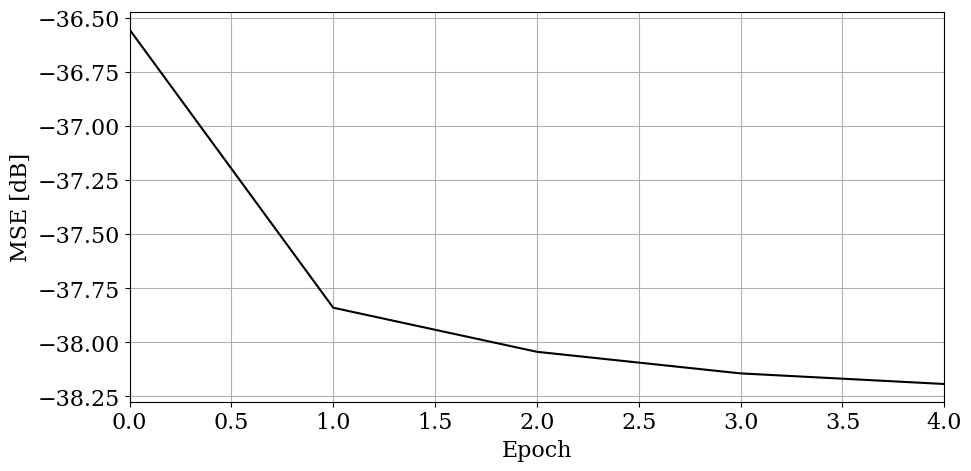

In [174]:
fig, axs = plt.subplots(figsize = (10, 5))
axs.plot(10*np.log10(errSq_hist), color = "k")

axs.set_xlim(0, paramTrain.numIter - 1)
axs.set_ylabel("MSE [dB]")
axs.set_xlabel("Epoch")
axs.grid()
plt.tight_layout()

In [175]:
sig_mp = MP_filter(sigIn, np.conj(w_ila).reshape( (P, M) ) )

MSE = -35.501 dB


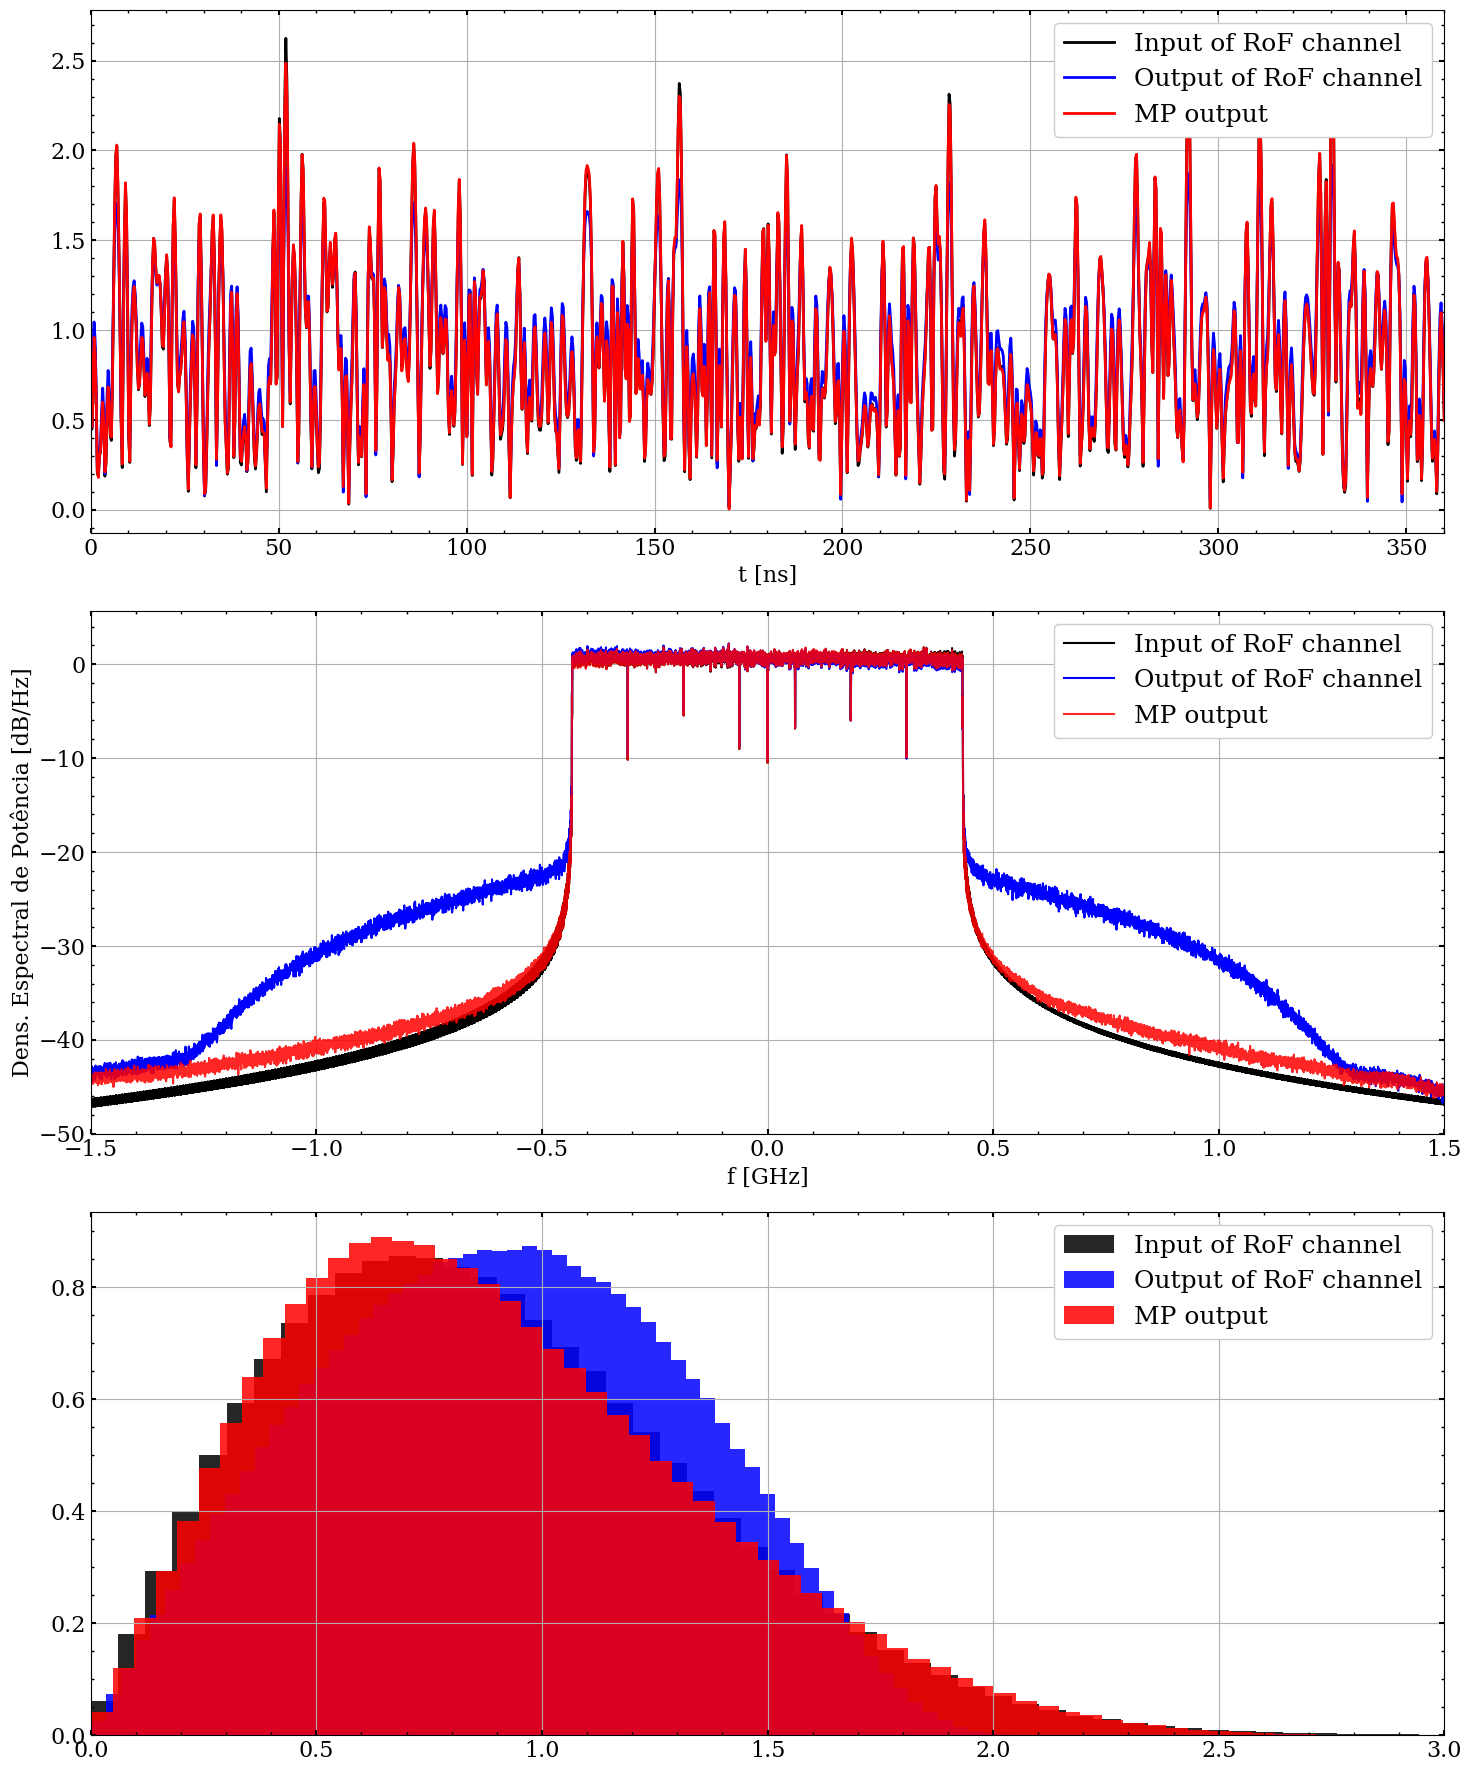

In [156]:
print(f"MSE = {10*np.log10(np.mean(np.abs(sig_mp - sigRef)**2)):.3f} dB")

indx = np.arange(0, int(10000*SpS_mp/SpS))
fig, axs = plt.subplots(3, 1, figsize = (15, 18))
t = np.arange(0, sigRef.size)*(1/Fs)*(SpS/SpS_mp)

axs[0].plot(t[indx]*1e9, np.abs(sigRef[indx]), "k", lw = 2, label = "Input of RoF channel")
axs[0].plot(t[indx]*1e9, np.abs(sigIn[indx]),  "b", lw = 2, label = "Output of RoF channel")
axs[0].plot(t[indx]*1e9, np.abs(sig_mp[indx]), "r", lw = 2, label = "MP output")

axs[0].set_xlim(0, np.max(t[indx])*1e9)
axs[0].legend(framealpha = 1, fontsize = 18, loc = "upper right")
axs[0].set_xlabel("t [ns]")
axs[0].grid()
axs[0].minorticks_on()
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

axs[1].psd(sigRef, Fs = (SpS_mp/SpS)*Fs/1e9, NFFT = 16*1024, sides = 'twosided', color = "k", label = "Input of RoF channel")
axs[1].psd(sigIn, Fs = (SpS_mp/SpS)*Fs/1e9, NFFT = 16*1024, sides = 'twosided', color = "b", label = "Output of RoF channel")
axs[1].psd(sig_mp, Fs = (SpS_mp/SpS)*Fs/1e9, NFFT = 16*1024, sides = 'twosided', color = "r", label = "MP output", alpha = 0.85)
axs[1].set_xlabel("f [GHz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(-1.5, 1.5)
axs[1].set_ylim(-50)
axs[1].grid(True)
axs[1].minorticks_on()
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs[1].legend(framealpha = 1, fontsize = 18, loc = "upper right")

axs[2].hist(np.abs(sigRef), density = True, bins = 64, color = "k", label = 'Input of RoF channel', alpha = 0.85)
axs[2].hist(np.abs(sigIn), density = True, bins = 64, color = "b", label = 'Output of RoF channel', alpha = 0.85)
axs[2].hist(np.abs(sig_mp), density = True, bins = 64, color = "r", label = 'MP output', alpha = 0.85)
axs[2].set_xlim(0, 3)
axs[2].grid()
axs[2].minorticks_on()
axs[2].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[2].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs[2].legend(framealpha = 1, fontsize = 18, loc = "upper right")

plt.tight_layout()
plt.show()

### 5 Arquitetura de Aprendizado Direto

In [ ]:
paramTrain = parameters()
paramTrain.M = M
paramTrain.P = P

paramTrain.N = 20_000
paramTrain.numIter = 5

paramTrain.mu  = 1/2
paramTrain.lbd = 0.9999
paramTrain.S   = np.eye(paramTrain.P*paramTrain.M, dtype = complex)*5e-2

paramTrain.alg  = "NFxRLS"
paramTrain.a_kl = a_kl
paramTrain.directLearn = True

paramTrain.pgrsBar    = True
paramTrain.showMSE    = False
paramTrain.storeCoeff = True

w_dla, errSq, w_hist, errSq_hist = MP_training(sigRef, paramTrain)

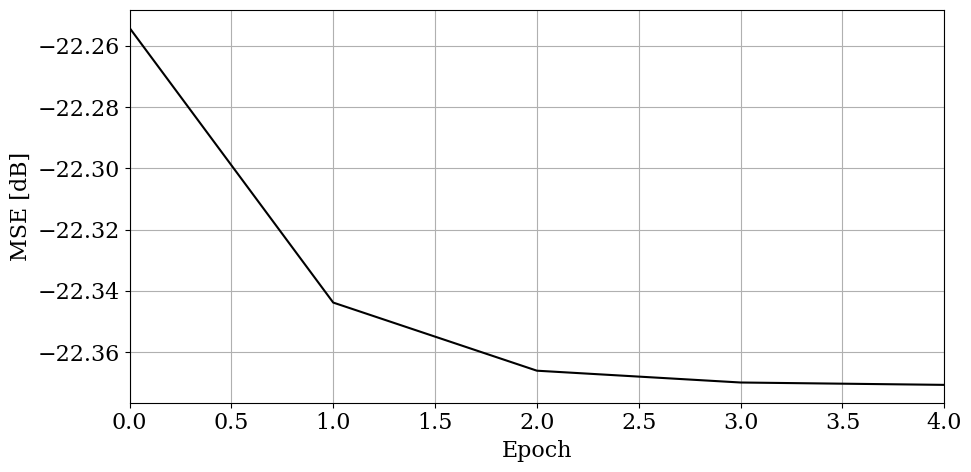

In [116]:
fig, axs = plt.subplots(figsize = (10, 5))
axs.plot(10*np.log10(errSq_hist), color = "k")

axs.set_xlim(0, paramTrain.numIter - 1)
axs.set_ylabel("MSE [dB]")
axs.set_xlabel("Epoch")
axs.grid()
plt.tight_layout()

In [117]:
sig_dpd = MP_filter(sigRef, np.conj(w_dla).reshape((P, M)))
sig_mp  = MP_filter(sig_dpd, a_kl)

MSE = -21.342 dB


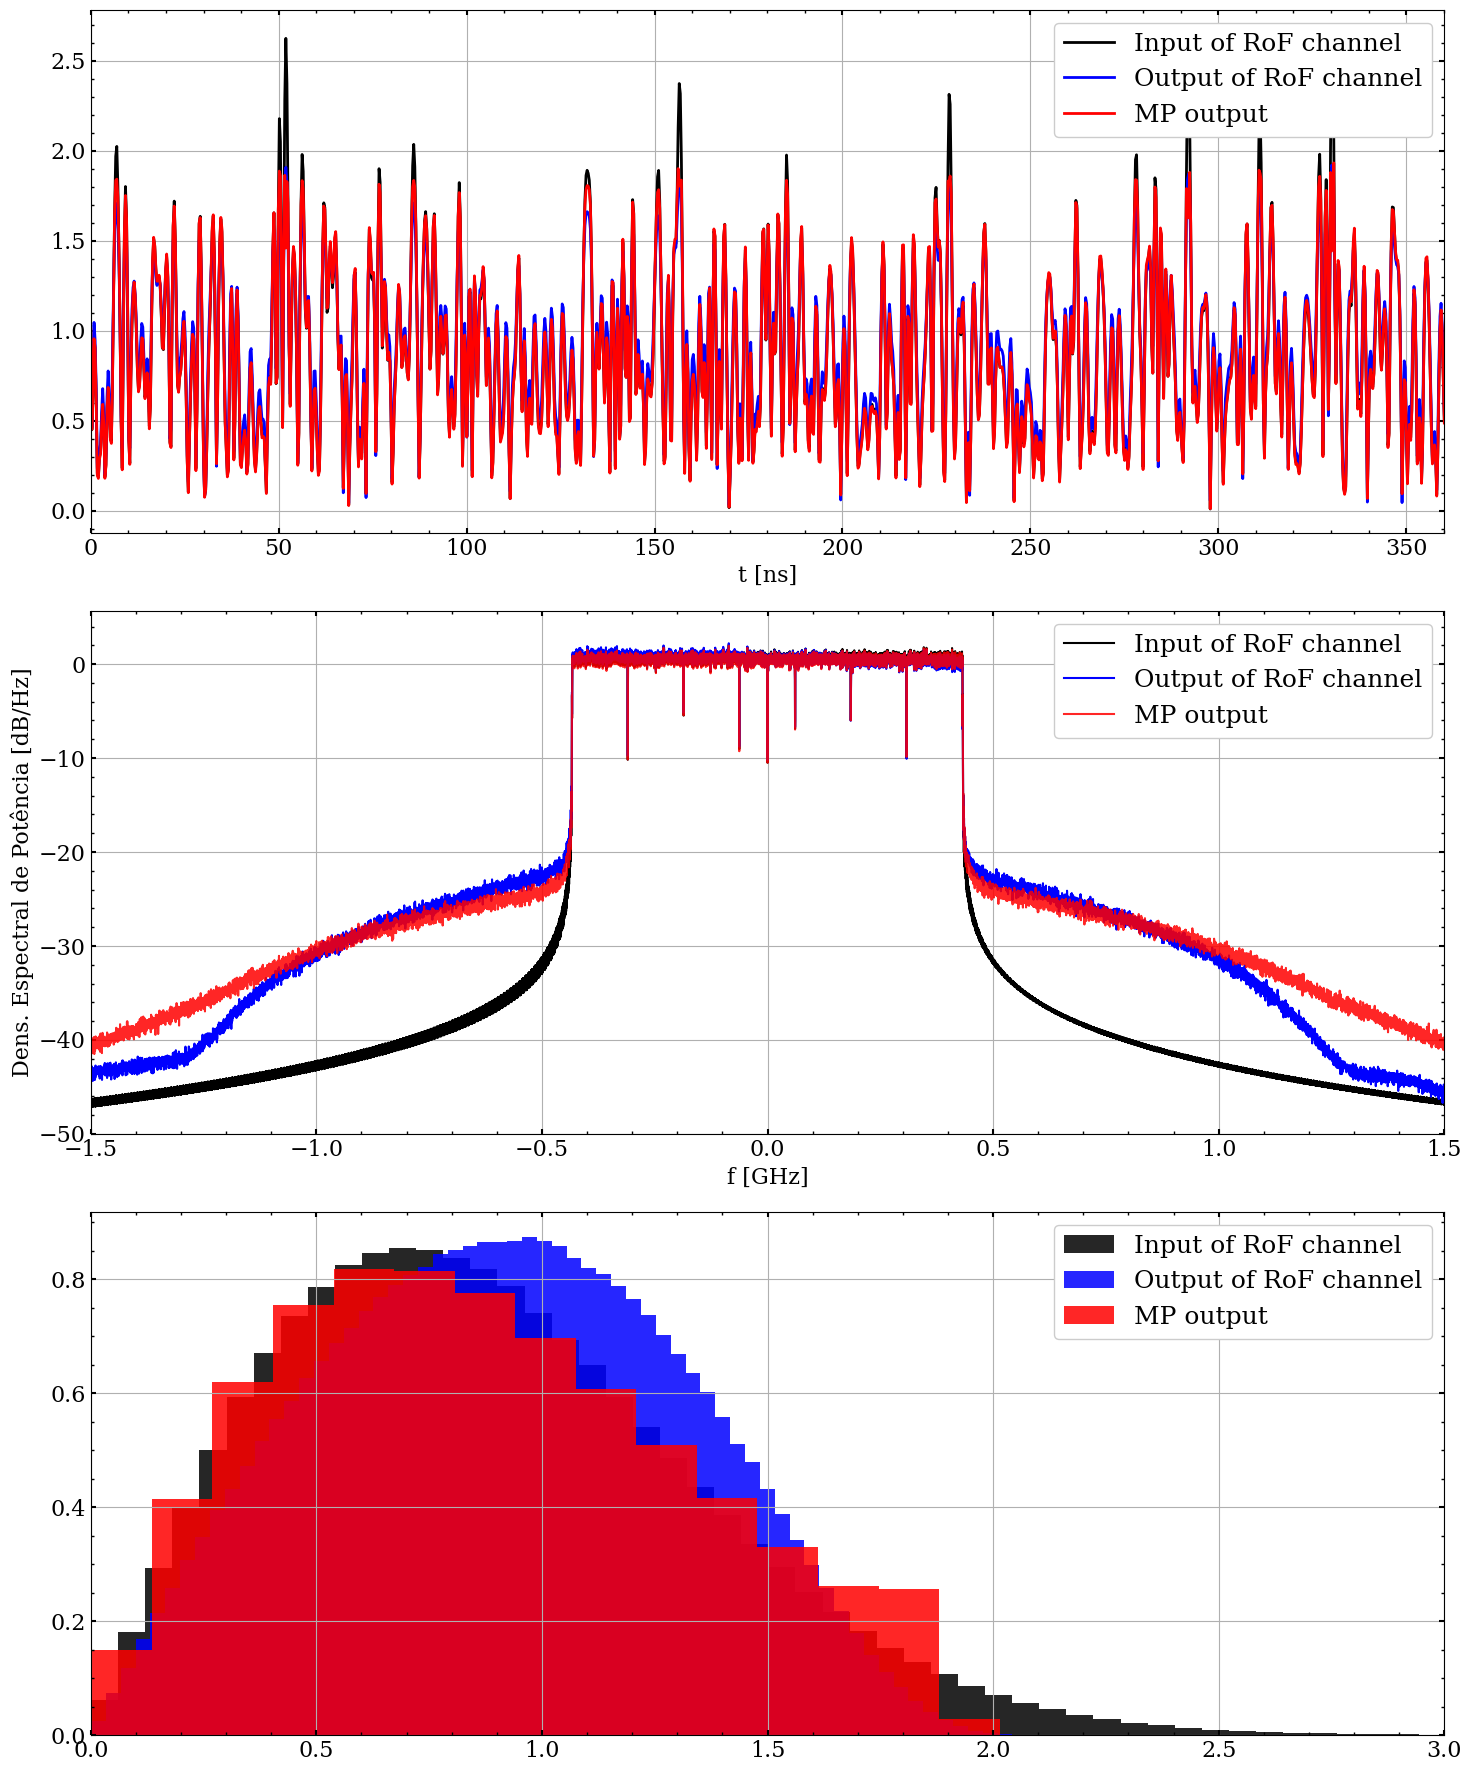

In [118]:
print(f"MSE = {10*np.log10(np.mean(np.abs(sig_mp - sigRef)**2)):.3f} dB")

indx = np.arange(0, int(10000*SpS_mp/SpS))
fig, axs = plt.subplots(3, 1, figsize = (15, 18))
t = np.arange(0, sigRef.size)*(1/Fs)*(SpS/SpS_mp)

axs[0].plot(t[indx]*1e9, np.abs(sigRef[indx]), "k", lw = 2, label = "Input of RoF channel")
axs[0].plot(t[indx]*1e9, np.abs(sigIn[indx]),  "b", lw = 2, label = "Output of RoF channel")
axs[0].plot(t[indx]*1e9, np.abs(sig_mp[indx]), "r", lw = 2, label = "MP output")

axs[0].set_xlim(0, np.max(t[indx])*1e9)
axs[0].legend(framealpha = 1, fontsize = 18, loc = "upper right")
axs[0].set_xlabel("t [ns]")
axs[0].grid()
axs[0].minorticks_on()
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

axs[1].psd(sigRef, Fs = (SpS_mp/SpS)*Fs/1e9, NFFT = 16*1024, sides = 'twosided', color = "k", label = "Input of RoF channel")
axs[1].psd(sigIn, Fs = (SpS_mp/SpS)*Fs/1e9, NFFT = 16*1024, sides = 'twosided', color = "b", label = "Output of RoF channel")
axs[1].psd(sig_mp, Fs = (SpS_mp/SpS)*Fs/1e9, NFFT = 16*1024, sides = 'twosided', color = "r", label = "MP output", alpha = 0.85)
axs[1].set_xlabel("f [GHz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(-1.5, 1.5)
axs[1].set_ylim(-50)
axs[1].grid(True)
axs[1].minorticks_on()
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs[1].legend(framealpha = 1, fontsize = 18, loc = "upper right")

axs[2].hist(np.abs(sigRef), density = True, bins = 64, color = "k", label = 'Input of RoF channel', alpha = 0.85)
axs[2].hist(np.abs(sigIn), density = True, bins = 64, color = "b", label = 'Output of RoF channel', alpha = 0.85)
axs[2].hist(np.abs(sig_mp), density = True, bins = 64, color = "r", label = 'MP output', alpha = 0.85)
axs[2].set_xlim(0, 3)
axs[2].grid()
axs[2].minorticks_on()
axs[2].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[2].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs[2].legend(framealpha = 1, fontsize = 18, loc = "upper right")

plt.tight_layout()
plt.show()

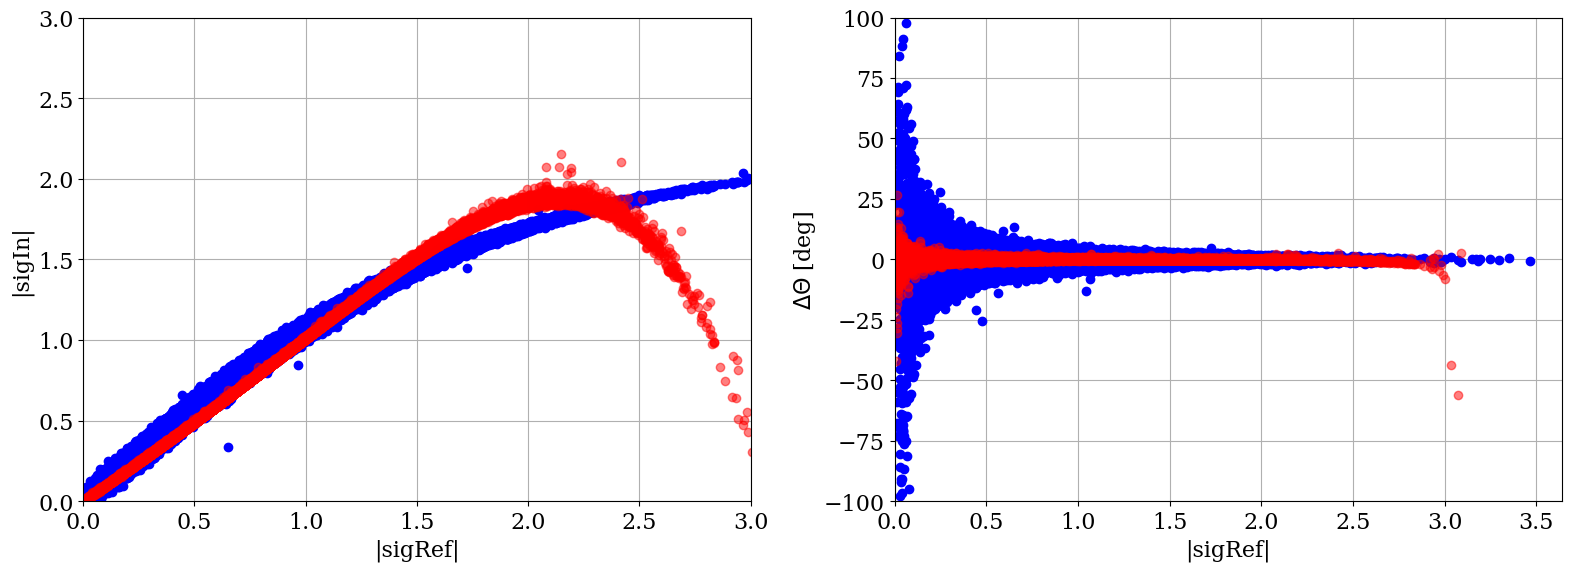

In [121]:
fig, axs = plt.subplots(1, 2, figsize = (16, 6))

n_pts = 100_000

axs[0].plot(np.abs(sigRef[0:n_pts]), np.abs(sigIn[0:n_pts]), "o", color = "b")
axs[0].plot(np.abs(sigRef[0:n_pts]), np.abs(sig_mp[0:n_pts]), "o", color = "r", alpha = 0.5)
axs[0].set_xlim(0, 3)
axs[0].set_ylim(0, 3)
axs[0].set_xlabel("|sigRef|")
axs[0].set_ylabel("|sigIn|")
axs[0].grid()

axs[1].plot(np.abs(sigRef[0:n_pts]), (np.angle(sigIn) - np.angle(sigRef))[0:n_pts]*180/pi, "o", color = "b")
axs[1].plot(np.abs(sigRef[0:n_pts]), (np.angle(sig_mp) - np.angle(sigRef))[0:n_pts]*180/pi, "o", color = "r", alpha = 0.5)
axs[1].set_xlim(0)
axs[1].set_ylim(-100, 100)
axs[1].set_xlabel("|sigRef|")
axs[1].set_ylabel("$\Delta \Theta$ [deg]")
axs[1].grid()

plt.tight_layout()

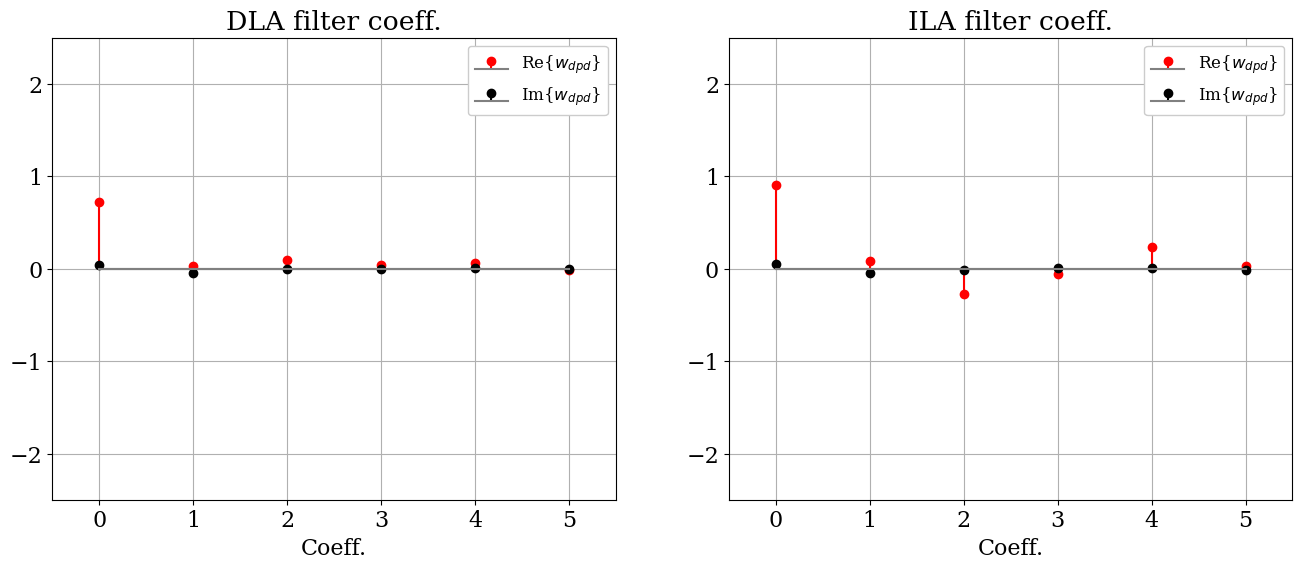

In [122]:
fig, axs = plt.subplots(1, 2, figsize = (16, 6))

markerline, stemlines, baseline = axs[0].stem(w_dla.real, linefmt = 'red',   markerfmt = 'o', basefmt = "gray", label = r"Re{$w_{dpd}$}")
markerline, stemlines, baseline = axs[0].stem(w_dla.imag, linefmt = 'black',   markerfmt = 'o', basefmt = "gray", label = r"Im{$w_{dpd}$}")

markerline, stemlines, baseline = axs[1].stem(w_ila.real, linefmt = 'red',   markerfmt = 'o', basefmt = "gray", label = r"Re{$w_{dpd}$}")
markerline, stemlines, baseline = axs[1].stem(w_ila.imag, linefmt = 'black',   markerfmt = 'o', basefmt = "gray", label = r"Im{$w_{dpd}$}")

axs[0].set_title("DLA filter coeff.")
axs[0].set_xlim(-0.5, P*M - 0.5)
axs[0].set_ylim(-2.5, 2.5)
axs[0].set_xlabel("Coeff.")
axs[0].legend(framealpha = 1, loc = "upper right", fontsize = 12)
axs[0].grid()

axs[1].set_title("ILA filter coeff.")
axs[1].set_xlim(-0.5, P*M - 0.5)
axs[1].set_ylim(-2.5, 2.5)
axs[1].set_xlabel("Coeff.")
axs[1].legend(framealpha = 1, loc = "upper right", fontsize = 12)
axs[1].grid()

### 6 - DPD Test

In [126]:
# Parâmetros OFDM
paramOFDM = parameters()
paramOFDM.Nfft = 1024                 # Tam. da FFT
paramOFDM.G    = 32                   # Tam. do prefixo cíclico
paramOFDM.hermitSymmetry = False
paramOFDM.SpS = SpS_mp

if paramOFDM.hermitSymmetry:
    Ns = paramOFDM.Nfft//2 - 1
    paramOFDM.pilotCarriers = np.linspace(0, Ns - 1, 8, dtype = np.int64)
    paramOFDM.nullCarriers  = np.array([], dtype = np.int64)
else:
    Ns = paramOFDM.Nfft
    paramOFDM.pilotCarriers = np.linspace(0, Ns - 1, 8, dtype = np.int64)
    paramOFDM.nullCarriers  = np.array([paramOFDM.Nfft//2], dtype = np.int64)

# Núm. de subportadoras de informação
Np = paramOFDM.pilotCarriers.size
Nz = paramOFDM.nullCarriers.size
Ni = Ns - Np - Nz

Rs = Rb / ( Ni/(paramOFDM.Nfft + paramOFDM.G) * np.log2(modOrder) )    # Taxa de transmissão de símbolos
Fs = Rs * SpS                                                          # Taxa de amostragem

# Geração dos bits e dos símbolos QAM
numOFDMframes = 500
np.random.seed(2)
bits = np.random.randint(2, size = (numOFDMframes*Ni, int(np.log2(modOrder))))

symbTx = modulateGray(bits, modOrder, modType)
symbTx = pnorm(symbTx)

pilotSymb = 0.25*(max(symbTx.real) + 1j*max(symbTx.imag))
paramOFDM.pilot = pilotSymb

In [127]:
sigTx = modulateOFDM(symbTx, paramOFDM)
sigTx = pnorm(sigTx)

sigTx_DPD_ILA = MP_filter(sigTx, np.conj(w_ila).reshape((P, M)))
sigTx_DPD_DLA = MP_filter(sigTx, np.conj(w_dla).reshape((P, M)))

In [128]:
P_DPD_DLA = signal_power(sigTx_DPD_DLA)
P_DPD_ILA = signal_power(sigTx_DPD_ILA)

In [129]:
numtaps = 4096
h_dpd = firwin(numtaps, 2*Rs, fs = Fs)

# ILA
sigTx_DPD_ILA = upsample(sigTx_DPD_ILA.ravel(), SpS//SpS_mp).reshape(-1,) 
sigTx_DPD_ILA = firFilter(h_dpd, sigTx_DPD_ILA)
sigTx_DPD_ILA = np.sqrt(P_DPD_ILA) * pnorm(sigTx_DPD_ILA)

# DLA
sigTx_DPD_DLA = upsample(sigTx_DPD_DLA.ravel(), SpS//SpS_mp).reshape(-1,) 
sigTx_DPD_DLA = firFilter(h_dpd, sigTx_DPD_DLA)
sigTx_DPD_DLA = np.sqrt(P_DPD_DLA) * pnorm(sigTx_DPD_DLA)

In [130]:
t = np.arange(0, sigTx_DPD_DLA.size)*1/Fs
t_CP   = SpS * paramOFDM.G * (1/Fs)
t_symb = SpS * (paramOFDM.Nfft + paramOFDM.G) * (1/Fs)

#### 6.1 Sinal RF

In [131]:
sigTx_RF_ILA = np.real( sigTx_DPD_ILA * np.exp(1j*2*pi*paramRF.fc_e*t) )
sigTx_RF_ILA *= G_1

sigTx_RF_DLA = np.real( sigTx_DPD_DLA * np.exp(1j*2*pi*paramRF.fc_e*t) )
sigTx_RF_DLA *= G_1

#### 6.2 Sinal óptico

In [132]:
Ai     = np.sqrt(dBm2W(paramMZM.Pin_OF))*np.ones(sigTx_RF_ILA.size)
sigTxo_ILA = mzm(Ai, sigTx_RF_ILA, paramMZM)

numtaps = 4096
hopt_tx = firwin(numtaps, paramRF.fc_e + 2*Rs, fs = Fs)
sigTxo_ILA = np.sqrt(signal_power(sigTxo_ILA))*pnorm(firFilter(hopt_tx, sigTxo_ILA))

sigRxo_ILA = linearFiberChannel(sigTxo_ILA, paramChannel)

print(f"P_Txo = {10*np.log10(signal_power(sigTxo_ILA)*1e3):.3f} dBm")
print(f"P_Rxo = {10*np.log10(signal_power(sigRxo_ILA)*1e3):.3f} dBm")

P_Txo = 6.990 dBm
P_Rxo = 1.990 dBm


In [133]:
Ai     = np.sqrt(dBm2W(paramMZM.Pin_OF))*np.ones(sigTx_RF_DLA.size)
sigTxo_DLA = mzm(Ai, sigTx_RF_DLA, paramMZM)

numtaps = 4096
hopt_tx = firwin(numtaps, paramRF.fc_e + 2*Rs, fs = Fs)
sigTxo_DLA = np.sqrt(signal_power(sigTxo_DLA))*pnorm(firFilter(hopt_tx, sigTxo_DLA))

sigRxo_DLA = linearFiberChannel(sigTxo_DLA, paramChannel)

print(f"P_Txo = {10*np.log10(signal_power(sigTxo_DLA)*1e3):.3f} dBm")
print(f"P_Rxo = {10*np.log10(signal_power(sigRxo_DLA)*1e3):.3f} dBm")

P_Txo = 6.990 dBm
P_Rxo = 1.990 dBm


#### 6.3 Sinal elétrico (fotocorrente)

In [134]:
I_Rx_ILA = photodiode(sigRxo_ILA, paramPD)
I_Rx_ILA -= I_Rx_ILA.mean()

In [135]:
I_Rx_DLA = photodiode(sigRxo_DLA, paramPD)
I_Rx_DLA -= I_Rx_DLA.mean()

#### 6.4 Sinal elétrico pós-FPF

In [136]:
# Filtro passa-faixas
numtaps = 4096
f1 = paramRF.fc_e - 2*Rs
f2 = paramRF.fc_e + 2*Rs
hbp_RF = firwin(numtaps, (f1, f2), pass_zero = 'bandpass', fs = Fs)

I_RF_ILA = firFilter(hbp_RF, I_Rx_ILA)
I_RF_DLA = firFilter(hbp_RF, I_Rx_DLA)

#### 6.5 Sinal elétrico pós-PA

In [137]:
sigRx_ILA = hilbert(I_RF_ILA)*np.exp(-1j*2*pi*paramRF.fc_e*t)
sigRx_ILA *= G_2

sigRx_ILA = powerAmplifier(sigRx_ILA)
sigRx_PA_DPD_ILA = sigRx_ILA.copy()
sigRx_PA_DPD_ILA *= G_3

numtaps = 4096
hlp = firwin(numtaps, Rs/1.5, fs = Fs)
#sigRx_ILA = firFilter(hlp, sigRx_ILA)

delay = finddelay(sigRx_ILA, sigTx_DPD_ILA)
sigRx_ILA = np.roll(sigRx_ILA, -delay)

rot = np.mean(sigTx_DPD_ILA/sigRx_ILA)
sigRx_ILA = rot/np.abs(rot)*sigRx_ILA

In [138]:
sigRx_DLA = hilbert(I_RF_DLA)*np.exp(-1j*2*pi*paramRF.fc_e*t)
sigRx_DLA *= G_2

sigRx_DLA = powerAmplifier(sigRx_DLA)
sigRx_PA_DPD_DLA = sigRx_DLA.copy()
sigRx_PA_DPD_DLA *= G_3

sigRx_PA_DPD_DLA = sigRx_DLA.copy()

numtaps = 4096
hlp = firwin(numtaps, Rs/1.5, fs = Fs)
#sigRx_DLA = firFilter(hlp, sigRx_DLA)

delay = finddelay(sigRx_DLA, sigTx_DPD_DLA)
sigRx_DLA = np.roll(sigRx_DLA, -delay)

rot = np.mean(sigTx_DPD_DLA/sigRx_DLA)
sigRx_DLA = rot/np.abs(rot)*sigRx_DLA

#### Perfomance

In [139]:
# Parâmetros da decimação
paramDec = parameters()
paramDec.SpS_in  = SpS
paramDec.SpS_out = 1

symbRx_OFDM = decimate(sigRx_ILA.copy(), paramDec).ravel()
symbRx_DPD_ILA = demodulateOFDM(symbRx_OFDM, paramOFDM)

symbRx_OFDM = decimate(sigRx_DLA.copy(), paramDec).ravel()
symbRx_DPD_DLA = demodulateOFDM(symbRx_OFDM, paramOFDM)

BER = 0.00000 
SNR = 27.262 dB 
EVM = 4.337 %


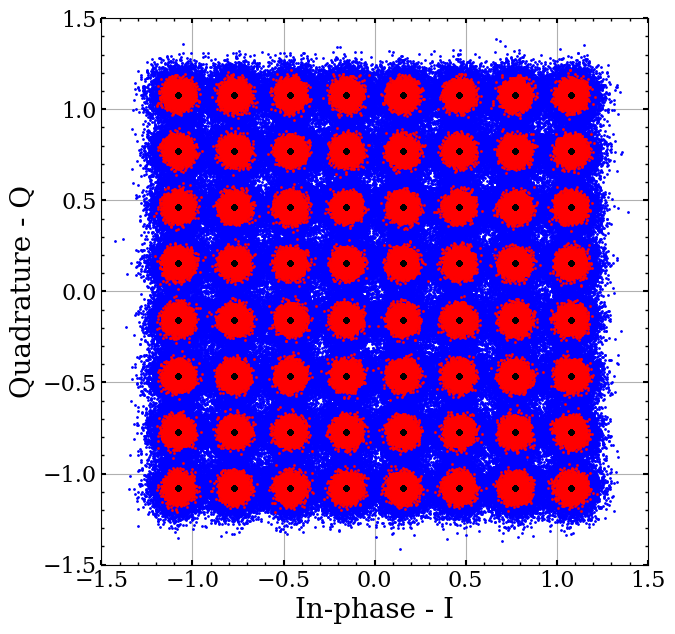

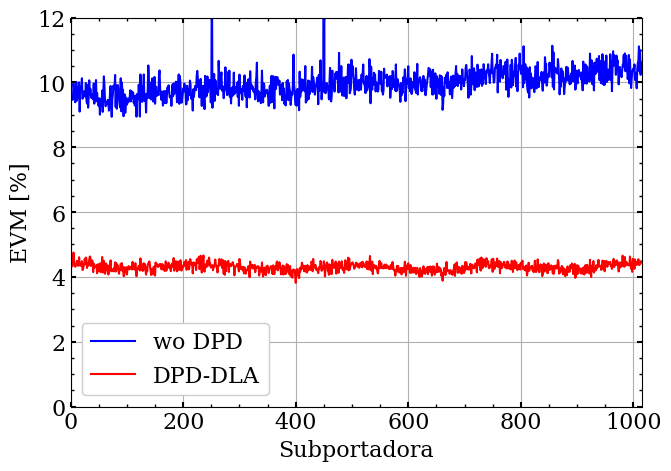

In [147]:
discard = Ni
index = np.arange(0, symbTx.size - discard)
BER, _, SNR = fastBERcalc(symbRx_DPD_DLA[index], symbTx[index], modOrder, modType)

EVM = np.sqrt(calcEVM(symbRx_DPD_DLA[index], modOrder, modType, symbTx[index]))*100

print(f"BER = {BER[0]:.5f} \nSNR = {SNR[0]:.3f} dB \nEVM = {EVM[0]:.3f} %")

# Normalização para o plot
symbTx = pnorm(symbTx)
symbRx_DPD_DLA = pnorm(symbRx_DPD_DLA)

fig, axs = plt.subplots(figsize = (7, 7))
axs.plot(symbRx[index].real, symbRx[index].imag, "o", color = "b", ms = 1, label = "No DPD")
axs.plot(symbRx_DPD_DLA[index].real, symbRx_DPD_DLA[index].imag, "o", color = "r", ms = 1, label = "NN-DPD")
axs.plot(symbTx.real, symbTx.imag, "o", color = "k", ms = 3, label = "SymbTx")
axs.set_ylabel("Quadrature - Q", fontsize = 20)
axs.set_xlabel("In-phase - I", fontsize = 20)
plt.axis("square")

axs.set_xlim(-1.5, 1.5)
axs.set_ylim(-1.5, 1.5)
axs.minorticks_on()
axs.tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs.tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

plt.grid()
plt.tight_layout()
#plt.savefig("constelacao_nnDPD.png")

_, SNR_per_carrier_DLA, EVM_per_carrier_DLA = calc_per_carrier(symbTx, symbRx_DPD_DLA, Ni, numOFDMframes)

fig, axs = plt.subplots(figsize = (7, 5))
axs.plot(EVM_per_carrier, color = "b", label = "wo DPD")
axs.plot(EVM_per_carrier_DLA, color = "r", label = "DPD-DLA")

axs.set_xlim(0, Ni)
axs.set_ylim(0, 12)
axs.set_ylabel("EVM [%]")
axs.set_xlabel("Subportadora")
axs.grid()
axs.minorticks_on()
axs.tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs.tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs.legend(framealpha = 1)
plt.tight_layout()

BER = 0.00000 
SNR = 29.764 dB 
EVM = 3.250 %


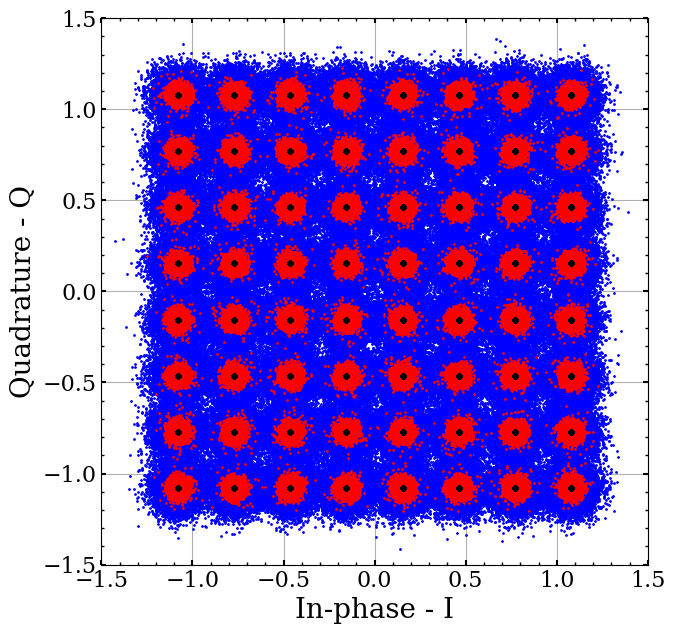

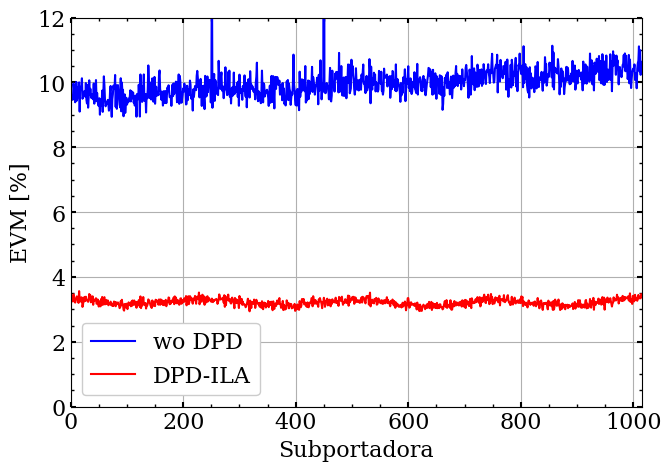

In [148]:
discard = Ni
index = np.arange(0, symbTx.size - discard)
BER, _, SNR = fastBERcalc(symbRx_DPD_ILA[index], symbTx[index], modOrder, modType)

EVM = np.sqrt(calcEVM(symbRx_DPD_ILA[index], modOrder, modType, symbTx[index]))*100

print(f"BER = {BER[0]:.5f} \nSNR = {SNR[0]:.3f} dB \nEVM = {EVM[0]:.3f} %")

# Normalização para o plot
symbTx = pnorm(symbTx)
symbRx_DPD_ILA = pnorm(symbRx_DPD_ILA)

fig, axs = plt.subplots(figsize = (7, 7))
axs.plot(symbRx[index].real, symbRx[index].imag, "o", color = "b", ms = 1, label = "No DPD")
axs.plot(symbRx_DPD_ILA[index].real, symbRx_DPD_ILA[index].imag, "o", color = "r", ms = 1, label = "NN-DPD")
axs.plot(symbTx.real, symbTx.imag, "o", color = "k", ms = 3, label = "SymbTx")
axs.set_ylabel("Quadrature - Q", fontsize = 20)
axs.set_xlabel("In-phase - I", fontsize = 20)
plt.axis("square")

axs.set_xlim(-1.5, 1.5)
axs.set_ylim(-1.5, 1.5)
axs.minorticks_on()
axs.tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs.tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

plt.grid()
plt.tight_layout()
#plt.savefig("constelacao_nnDPD.png")

_, SNR_per_carrier_ILA, EVM_per_carrier_ILA = calc_per_carrier(symbTx, symbRx_DPD_ILA, Ni, numOFDMframes)

fig, axs = plt.subplots(figsize = (7, 5))
axs.plot(EVM_per_carrier, color = "b", label = "wo DPD")
axs.plot(EVM_per_carrier_ILA, color = "r", label = "DPD-ILA")

axs.set_xlim(0, Ni)
axs.set_ylim(0, 12)
axs.set_ylabel("EVM [%]")
axs.set_xlabel("Subportadora")
axs.grid()
axs.minorticks_on()
axs.tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs.tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs.legend(framealpha = 1)
plt.tight_layout()

In [150]:
freq, P_sigTx            = welch(pnorm(sigTx), fs = SpS_mp*Rs, nfft = 16*1024, return_onesided = False)
freq, P_sigRx_PA         = welch(pnorm(sigRx_PA)[0::SpS//SpS_mp], fs = SpS_mp*Rs, nfft = 16*1024, return_onesided = False)
freq, P_sigRx_PA_DPD_DLA = welch(pnorm(sigRx_PA_DPD_DLA)[0::SpS//SpS_mp], fs = SpS_mp*Rs, nfft = 16*1024, return_onesided = False)
freq, P_sigRx_PA_DPD_ILA = welch(pnorm(sigRx_PA_DPD_ILA)[0::SpS//SpS_mp], fs = SpS_mp*Rs, nfft = 16*1024, return_onesided = False)

SigTx - ACLR = -34.606 dB
SigRx PA w/o DPD - ACLR = -25.281 dB
SigRx PA w DPD-ILA - ACLR = -31.397 dB
SigRx PA w DPD-DLA - ACLR = -30.294 dB


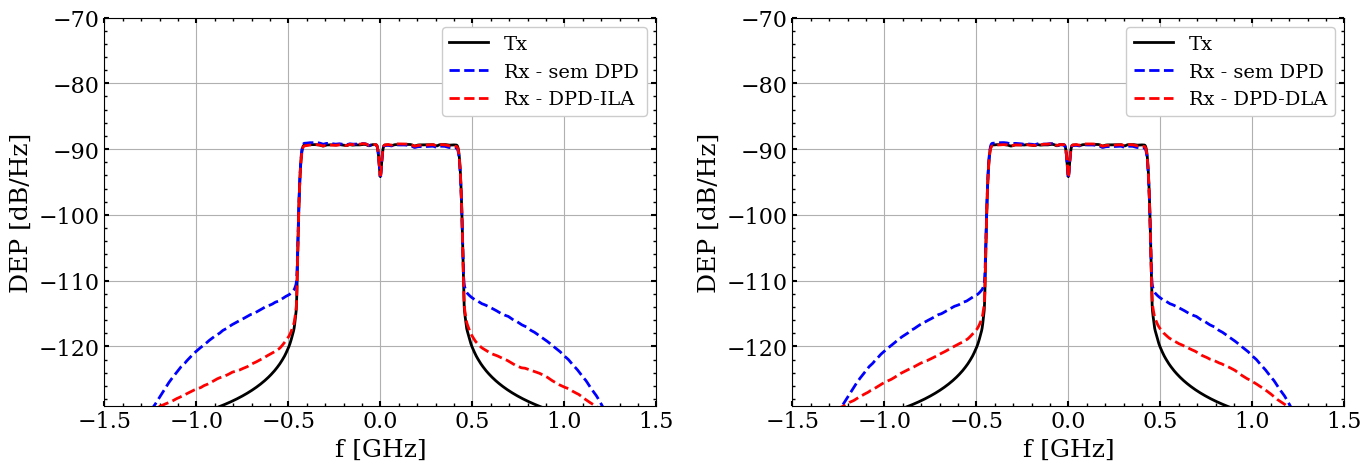

In [152]:
print(f"SigTx - ACLR = {calcACLR(P_sigTx, freq, 0.5e9):.3f} dB")
print(f"SigRx PA w/o DPD - ACLR = {calcACLR(P_sigRx_PA, freq, 0.5e9):.3f} dB")
print(f"SigRx PA w DPD-ILA - ACLR = {calcACLR(P_sigRx_PA_DPD_ILA, freq, 0.5e9):.3f} dB")
print(f"SigRx PA w DPD-DLA - ACLR = {calcACLR(P_sigRx_PA_DPD_DLA, freq, 0.5e9):.3f} dB")

fig, axs = plt.subplots(1, 2, figsize = (14, 5))

axs[0].plot(freq/1e9, 10*np.log10(P_sigTx), lw = 2, color = "k", label = "Tx")
axs[0].plot(freq/1e9, 10*np.log10(P_sigRx_PA), lw = 2, color = "b", label = "Rx - sem DPD", ls = "--")
axs[0].plot(freq/1e9, 10*np.log10(P_sigRx_PA_DPD_ILA), lw = 2, color = "r", label = "Rx - DPD-ILA", ls = "--")
axs[0].set_xlim(-1.5, 1.5)
axs[0].set_ylim(-129, -70)

axs[0].set_ylabel("DEP [dB/Hz]", fontsize = 18)
axs[0].set_xlabel("f [GHz]", fontsize = 18)
axs[0].legend(framealpha = 1, fontsize = 14, loc = "upper right")

axs[0].minorticks_on()
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs[0].grid()

axs[1].plot(freq/1e9, 10*np.log10(P_sigTx), lw = 2, color = "k", label = "Tx")
axs[1].plot(freq/1e9, 10*np.log10(P_sigRx_PA), lw = 2, color = "b", label = "Rx - sem DPD", ls = "--")
axs[1].plot(freq/1e9, 10*np.log10(P_sigRx_PA_DPD_DLA), lw = 2, color = "r", label = "Rx - DPD-DLA", ls = "--")
axs[1].set_xlim(-1.5, 1.5)
axs[1].set_ylim(-129, -70)

axs[1].set_ylabel("DEP [dB/Hz]", fontsize = 18)
axs[1].set_xlabel("f [GHz]", fontsize = 18)
axs[1].legend(framealpha = 1, fontsize = 14, loc = "upper right")

axs[1].minorticks_on()
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs[1].grid()

plt.tight_layout()
#plt.savefig("sig_freq_mpDPD.pdf")